# Machine Learning Models & Techniques Study Notebook
**Written:** 07/20/2026 - 07/21/2026

A reference notebook covering the supervised models, unsupervised models, and ML techniques I know.
**This was made with the help of ClaudeAI to save time, I still proofread the whole notebook.**
Each entry follows the same structure:

1. **What it does / how it works**
2. **Tunable parameters**
3. **Mathematical pipeline**
4. **Mini manual example** (worked by hand)
5. **Code implementation**
6. **Strengths & weaknesses**
7. **Scenario use cases**
8. **Key evaluation metrics**
9. **Key statistical concepts**

---

## Table of Contents

**Supervised Learning**
1. [Linear Regression (OLS)](#lr)
2. [Linear Probability Model (LPM)](#lpm)
3. [Logistic Regression](#logit)
4. [Generalized Linear Model (GLM)](#glm)
5. [K-Nearest Neighbors (KNN)](#knn)
6. [Decision Trees (DT)](#dt)
7. [Bagging](#bagging)
8. [Random Forest (RF)](#rf)
9. [AdaBoost](#ada)
10. [Gradient Boosting](#gb)
11. [XGBoost](#xgb)
12. [Ridge Regression (L2)](#ridge)
13. [Lasso Regression (L1)](#lasso)
14. [Elastic Net](#enet)

**Unsupervised Learning**  

15. [K-Means Clustering](#kmeans)  
16. [DBSCAN](#dbscan)

**Methods / Techniques**  

17. [Pipelines](#pipeline)  
18. [Dimensionality Reduction (PCA, t-SNE, UMAP)](#dimred)  
19. [Market Basket Analysis](#mba)  
20. [Natural Language Processing (NLP)](#nlp)  
21. [Text Clustering & Topic Modeling](#topicmodel)  
22. [Class Imbalance Handling (SMOTE, RUS, etc.)](#imbalance)


<a id='metrics-glossary'></a>
# Classification Metrics Glossary

Most classification sections below reference these metrics under **Key Evaluation Metrics** — defined once here instead of repeating the definitions at every model.

## The Confusion Matrix
For a binary classifier at a chosen probability threshold, every prediction falls into one of four buckets:

|                | Predicted Positive | Predicted Negative |
|----------------|---------------------|----------------------|
| **Actual Positive** | True Positive (TP) — correctly caught | False Negative (FN) — missed (Type II error) |
| **Actual Negative** | False Positive (FP) — false alarm (Type I error) | True Negative (TN) — correctly rejected |

## Metrics derived from the confusion matrix
- **Accuracy** — overall fraction correct: $\dfrac{TP+TN}{TP+TN+FP+FN}$. Misleading under class imbalance (a model that always predicts the majority class can still score high).
- **Precision** — of everything predicted positive, how much was actually positive: $\dfrac{TP}{TP+FP}$. High precision = few false alarms.
- **Recall (Sensitivity / TPR)** — of everything actually positive, how much did the model catch: $\dfrac{TP}{TP+FN}$. High recall = few missed positives.
- **F1-score** — harmonic mean of Precision and Recall, balancing the two: $F1 = \dfrac{2 \cdot Precision \cdot Recall}{Precision+Recall}$. Useful when both false positives and false negatives are costly.
- **Specificity (TNR)** — of everything actually negative, how much was correctly rejected: $\dfrac{TN}{TN+FP}$.

## Threshold-independent metrics
- **ROC-AUC** — area under the Receiver Operating Characteristic curve (True Positive Rate vs. False Positive Rate across all thresholds); the probability the model ranks a random positive above a random negative. 0.5 = random guessing, 1.0 = perfect separation.
- **Precision-Recall AUC** — area under the Precision vs. Recall curve across all thresholds; more informative than ROC-AUC when the positive class is rare.
- **Log-loss (cross-entropy)** — penalizes confident-but-wrong probabilities directly (lower is better); measures calibration, not just the final class decision.

Below, "Confusion Matrix" as a metric means computing this table (and the ratios above) on held-out predictions to see exactly *where* the model is making mistakes, rather than relying on Accuracy alone.

---


In [1]:
# Shared imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
print("Environment ready.")

Environment ready.


In [ ]:
# --- Global warning suppression (run this once, before anything else) ---
# This uses warnings.warn() monkey-patching rather than just filterwarnings('ignore'),
# because in notebooks some libraries (matplotlib inline backend, sklearn, etc.) reset
# the warnings filter list mid-session, which silently undoes a plain filterwarnings('ignore')
# called earlier. Overriding warnings.warn directly is immune to that.
import warnings

def _silence(*args, **kwargs):
    pass

warnings.warn = _silence
warnings.filterwarnings('ignore')  # belt-and-suspenders for warnings issued via other paths
print("Warnings suppressed for this session.")

<a id='lr'></a>
# 1. Linear Regression (Ordinary Least Squares)

## What it does / How it works
Linear Regression models a **continuous** target $y$ as a weighted linear combination of
predictors $X$. "Ordinary Least Squares" (OLS) is the fitting method: it finds the
coefficients $\beta$ that **minimize the sum of squared residuals** (vertical distances
between actual and predicted points). Geometrically, OLS finds the hyperplane that best
fits the cloud of points in the least-squares sense.

## Tunable Parameters
Classic OLS has no regularization hyperparameters to tune as it's a closed-form solution.
In `sklearn.linear_model.LinearRegression`, the practical knobs are:
- `fit_intercept` (bool) — whether to estimate $\beta_0$
- `positive` (bool) — force coefficients to be non-negative
- Feature engineering choices (which predictors, interactions, polynomial terms) are the
  real "tuning" in OLS since there's no penalty term.

## Mathematical Pipeline
Model: $\hat{y} = X\beta = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_px_p$

Objective (minimize Residual Sum of Squares):
$$RSS(\beta) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = (y - X\beta)^T(y - X\beta)$$

Closed-form (Normal Equation) solution, found by setting $\partial RSS/\partial \beta = 0$:
$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

Assumptions (LINE): **L**inearity, **I**ndependence of errors, **N**ormality of residuals,
**E**qual variance (homoscedasticity); plus no severe multicollinearity.

## Mini Manual Example
Data: $x = [1,2,3,4]$, $y = [2,3,5,4]$. Fit $\hat y = \beta_0 + \beta_1 x$.

$\bar x = 2.5,\ \bar y = 3.5$

$\beta_1 = \dfrac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i - \bar x)^2}$

Deviations: $x-\bar x = [-1.5,-0.5,0.5,1.5]$, $y-\bar y=[-1.5,-0.5,1.5,0.5]$

Numerator $= (-1.5)(-1.5)+(-0.5)(-0.5)+(0.5)(1.5)+(1.5)(0.5) = 2.25+0.25+0.75+0.75 = 4.0$

Denominator $= 1.5^2+0.5^2+0.5^2+1.5^2 = 2.25+0.25+0.25+2.25 = 5.0$

$\beta_1 = 4/5 = 0.8$, $\beta_0 = \bar y - \beta_1\bar x = 3.5 - 0.8(2.5) = 1.5$

Fitted line: $\hat y = 1.5 + 0.8x$ → predictions $[2.3, 3.1, 3.9, 4.7]$

## Strengths & Weaknesses
**Strengths:**
- highly interpretable coefficients.
- fast closed-form fit.
- well-understood statistical inference (p-values, CIs).
- good baseline model.

**Weaknesses:**
- assumes linearity.
- sensitive to outliers.
- breaks down with multicollinearity (unstable/undefined coefficients).
- no built-in regularization → prone to overfitting with many predictors.
- sensitive to violated assumptions.

## Scenario Use Cases
- Predicting continuous outcomes (house prices, sales, temperature) where relationships are
  roughly linear.
- When interpretability of "how much does y change per unit of x" matters (economics, policy).
- Quick baseline before trying more complex models.

## Key Evaluation Metrics
- **R² (coefficient of determination):** proportion of variance in $y$ explained by the
  model. $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$. Ranges (typically) 0–1; higher is better.
- **Adjusted R²:** penalizes R² for adding predictors that don't improve fit —
  $R^2_{adj} = 1-(1-R^2)\frac{n-1}{n-p-1}$. Use this over R² when comparing models with
  different numbers of predictors.
- **RMSE / MAE:** average prediction error in original units (RMSE penalizes large errors
  more than MAE).
- **F-statistic:** tests whether the model as a whole is statistically significant (at least
  one $\beta \neq 0$).

## Key Statistical Concepts
- **Beta coefficient interpretation:** $\beta_j$ = expected change in $y$ for a one-unit
  increase in $x_j$, **holding all other predictors constant**. Sign indicates direction,
  magnitude indicates strength (careful comparing magnitudes across differently-scaled
  variables standardize first).
- **p-value (per coefficient):** probability of observing a coefficient this extreme if the
  true coefficient were 0 (null hypothesis $H_0: \beta_j=0$). Typically p < 0.05 is deemed
  "statistically significant."
- **Standard error / confidence interval:** quantifies uncertainty around each $\hat\beta$.
- **Multicollinearity (VIF):** Variance Inflation Factor > 5–10 signals predictors are
  correlated with each other, inflating standard errors and destabilizing coefficients.
- **Homoscedasticity / residual plots:** used to visually check assumption of constant
  error variance.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import warnings

# toy data
X = np.array([[1],[2],[3],[4]])
y = np.array([2,3,5,4])

# --- sklearn: prediction-focused ---
lr = LinearRegression()
lr.fit(X, y)
print("sklearn coef:", lr.coef_, "intercept:", lr.intercept_)
print("predictions:", lr.predict(X))

# --- statsmodels: inference-focused (p-values, R^2, adj R^2, F-stat) ---
X_sm = sm.add_constant(X)  # adds intercept column

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = sm.OLS(y, X_sm).fit()
    summary = model.summary()

print(summary)

sklearn coef: [0.8] intercept: 1.5000000000000007
predictions: [2.3 3.1 3.9 4.7]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     3.556
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.200
Time:                        05:56:06   Log-Likelihood:                -4.0787
No. Observations:                   4   AIC:                             12.16
Df Residuals:                       2   BIC:                             10.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<a id='lpm'></a>
# 2. Linear Probability Model (LPM)

## What it does / How it works
LPM applies **ordinary OLS mechanics** to a **binary** (0/1) outcome. Instead of predicting
a probability with a sigmoid (as logistic regression does), it just fits a straight
line/hyperplane to the 0/1 target, and the fitted value is interpreted as $P(y=1|X)$.

## Tunable Parameters
Same as OLS — no built-in regularization; `fit_intercept`, choice of predictors/interactions.
Practitioners sometimes apply **robust (heteroskedasticity-consistent) standard errors**
since LPM residuals are mechanically heteroscedastic.

## Mathematical Pipeline
Model: $P(y_i=1|X_i) = \beta_0 + \beta_1x_{1i} + \dots + \beta_px_{pi}$, fit via the same
normal equation as OLS: $\hat\beta = (X^TX)^{-1}X^Ty$ where $y\in\{0,1\}$.

Key issue: predicted values $\hat y$ are **not bounded** to $[0,1]$ — can be negative or
>1, which is nonsensical for a probability.

## Mini Manual Example
Data: $x=[1,2,3,4]$ (hours studied), $y=[0,0,1,1]$ (pass/fail).
$\bar x=2.5, \bar y=0.5$

$\beta_1 = \frac{\sum(x-\bar x)(y-\bar y)}{\sum(x-\bar x)^2}$

Deviations: $x-\bar x=[-1.5,-0.5,0.5,1.5]$, $y-\bar y=[-0.5,-0.5,0.5,0.5]$

Numerator $=0.75+0.25+0.25+0.75=2.0$; Denominator $=5.0$ → $\beta_1=0.4$

$\beta_0 = 0.5 - 0.4(2.5) = -0.5$

Fitted probabilities: $\hat y = -0.5+0.4x$ → $x=1\to -0.1$ (!), $x=2\to0.3$, $x=3\to0.7$,
$x=4\to1.1$ (!) — illustrates the out-of-bounds problem directly.

## Strengths & Weaknesses
**Strengths:**
- extremely simple/fast.
- coefficients directly interpretable as **change in probability** per unit x (no log-odds transform needed).
- good for quick marginal-effect estimates in economics/social science.

**Weaknesses:**
- predicted probabilities can fall outside [0,1].
- residuals are inherently heteroscedastic (variance depends on $x$).
- violates OLS assumptions.
- poor for classification tasks needing calibrated probabilities near 0 or 1.

## Scenario Use Cases
- Econometrics / causal inference settings where the interpretability of a direct
  probability-change coefficient outweighs the boundary issue, especially when most fitted
  probabilities lie away from 0/1 extremes.
- Quick, simple approximation before moving to logistic regression.

## Key Evaluation Metrics
- **Accuracy / Confusion Matrix** (after thresholding, e.g. $\hat y > 0.5 \to 1$) — see the [Metrics Glossary](#metrics-glossary) for how TP/FP/TN/FN and their derived ratios (Precision, Recall, F1) are computed.
- **R² / Adjusted R²** — still reported but less meaningful than in continuous OLS.
- **Robust (White) standard errors** used instead of ordinary SEs to correct for known
  heteroscedasticity.

## Key Statistical Concepts
- **Beta interpretation:** $\beta_j$ = the change in the **probability** that $y=1$ for a
  one-unit increase in $x_j$ (a direct, linear marginal effect — unlike logit's log-odds).
- **Heteroskedasticity:** because $Var(y|X) = p(1-p)$ for a Bernoulli outcome, and $p$
  changes with $X$, error variance is never constant — this is a structural feature of LPM.
- **p-values** still test $H_0:\beta_j=0$ but rely on robust SEs for validity.

In [3]:
import statsmodels.api as sm
import warnings

X = np.array([1,2,3,4])
y = np.array([0,0,1,1])
X_sm = sm.add_constant(X)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lpm = sm.OLS(y, X_sm).fit(cov_type='HC1')  # robust SEs
    summary = lpm.summary()

print(summary)
print("\nFitted probabilities (note: can exceed [0,1]):", lpm.fittedvalues)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     22.22
Date:                Mon, 20 Jul 2026   Prob (F-statistic):             0.0422
Time:                        05:56:06   Log-Likelihood:                0.31571
No. Observations:                   4   AIC:                             3.369
Df Residuals:                       2   BIC:                             2.141
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5000      0.265     -1.890      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<a id='logit'></a>
# 3. Logistic Regression

## What it does / How it works
Logistic Regression predicts the **probability** that a binary outcome equals 1 by passing
a linear combination of predictors through the **sigmoid (logistic) function**, which
squashes any real number into the range (0,1). Unlike LPM, it can never predict outside
[0,1]. Coefficients are estimated via **Maximum Likelihood Estimation (MLE)**, not OLS.

## Tunable Parameters (sklearn `LogisticRegression`)
- `penalty` — `'l1'`, `'l2'`, `'elasticnet'`, `'none'` (regularization type)
- `C` — inverse of regularization strength (smaller C = stronger regularization)
- `solver` — optimization algorithm (`'lbfgs'`, `'liblinear'`, `'saga'`, etc.)
- `max_iter` — iterations allowed for the solver to converge
- `class_weight` — reweight classes (useful for imbalance)
- `multi_class` — `'ovr'` or `'multinomial'` for >2 classes

## Mathematical Pipeline
Linear predictor (log-odds / logit): $z = \beta_0+\beta_1x_1+\dots+\beta_px_p$

Sigmoid link: $\hat p = P(y=1|X) = \dfrac{1}{1+e^{-z}}$

Log-odds form: $\ln\left(\dfrac{\hat p}{1-\hat p}\right) = z$

Loss function (negative log-likelihood / log-loss), minimized via gradient descent /
Newton-Raphson (no closed form):
$$\mathcal{L}(\beta) = -\sum_{i=1}^n \big[y_i\ln(\hat p_i) + (1-y_i)\ln(1-\hat p_i)\big]$$

## Mini Manual Example
Suppose a fitted model gives $\beta_0=-4$, $\beta_1=0.8$ (hours studied → pass). For a
student who studied $x=5$ hours:

$z = -4 + 0.8(5) = 0$

$\hat p = \dfrac{1}{1+e^{-0}} = \dfrac{1}{2} = 0.5$ → 50% chance of passing.

For $x=6$: $z=-4+0.8(6)=0.8$, $\hat p = 1/(1+e^{-0.8}) = 1/(1+0.449) = 0.690$ → 69% chance.

Odds ratio for a 1-unit increase in x: $e^{\beta_1} = e^{0.8} = 2.23$ → each extra hour of
study **more than doubles the odds** of passing.

## Strengths & Weaknesses
**Strengths:**
- outputs valid probabilities.
- coefficients interpretable via odds ratios.
- efficient and well-regularized variants exist.
- works well when classes are roughly linearly separable in log-odds space.

**Weaknesses:**
- assumes linearity in the logit.
- struggles with complex non-linear boundaries.
- sensitive to multicollinearity.
- can be biased under severe class imbalance without adjustment.

## Scenario Use Cases
- Any binary classification with a need for interpretable, calibrated probabilities:
  credit default, churn, disease diagnosis, spam detection, marketing conversion.
- When stakeholders need to explain "why" via odds ratios (e.g., medical/credit risk models).

## Key Evaluation Metrics
- **Accuracy, Precision, Recall, F1** — from the confusion matrix at a chosen threshold.
- **ROC-AUC** — probability the model ranks a random positive higher than a random negative;
  threshold-independent.
- **Log-loss (cross-entropy)** — directly measures calibration quality of predicted
  probabilities (lower is better).
- **Confusion Matrix** — the TP/FP/TN/FN breakdown that Accuracy, Precision, Recall, and F1 above are computed from; see the [Metrics Glossary](#metrics-glossary) for the full definitions and formulas.

## Key Statistical Concepts
- **Beta / odds-ratio interpretation:** $e^{\beta_j}$ = multiplicative change in the **odds**
  of $y=1$ for a one-unit increase in $x_j$, holding others constant. $e^{\beta_j}>1$
  increases odds, $<1$ decreases odds.
- **Pseudo R² (McFadden's):** $R^2_{McF} = 1 - \frac{\ln L_{full}}{\ln L_{null}}$ — analog to
  R² for MLE models (0.2–0.4 is often considered a good fit; not directly comparable to OLS R²).
- **p-values (Wald test):** test $H_0:\beta_j=0$ using $z = \hat\beta_j/SE(\hat\beta_j)$.
- **AIC/BIC:** information criteria for comparing models — penalize complexity; lower is better.

In [4]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

X = np.array([1,2,3,4,5,6,7,8,3.5,5.5]).reshape(-1,1)
y = np.array([0,0,0,0,1,1,1,1,1,0])  # slight overlap avoids perfect separation

clf = LogisticRegression()
clf.fit(X, y)
print("coef (log-odds):", clf.coef_, "intercept:", clf.intercept_)
print("odds ratio per unit x:", np.exp(clf.coef_))
print("predicted probabilities:", clf.predict_proba(X)[:,1])

# statsmodels for p-values / pseudo R^2 / AIC
X_sm = sm.add_constant(X)
logit_model = sm.Logit(y, X_sm).fit(disp=0)
print(logit_model.summary())

coef (log-odds): [[0.7828]] intercept: [-3.5225]
odds ratio per unit x: [[2.1876]]
predicted probabilities: [0.0607 0.1238 0.2361 0.4034 0.5966 0.7639 0.8762 0.9393 0.3137 0.6863]
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   10
Model:                          Logit   Df Residuals:                        8
Method:                           MLE   Df Model:                            1
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                  0.3949
Time:                        05:56:06   Log-Likelihood:                -4.1944
converged:                       True   LL-Null:                       -6.9315
Covariance Type:            nonrobust   LLR p-value:                   0.01930
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5783      2.8

<a id='glm'></a>
# 4. Generalized Linear Model (GLM)

## What it does / How it works
GLM is the **umbrella framework** that unifies OLS, Logistic Regression, Poisson
Regression, and more under one structure. Every GLM has three components:
1. **Random component** — the assumed probability distribution of $y$ (Normal, Binomial,
   Poisson, Gamma, etc. from the exponential family)
2. **Systematic component** — the linear predictor $\eta = X\beta$
3. **Link function** — connects the mean of $y$ to the linear predictor: $g(\mu)=\eta$

Choosing the distribution + link recovers familiar models: Normal + identity link = OLS;
Binomial + logit link = Logistic Regression; Poisson + log link = Poisson Regression (counts).

## Tunable Parameters
- `family` — distribution assumption (Gaussian, Binomial, Poisson, Gamma, InverseGaussian...)
- `link` — link function (identity, logit, log, probit, inverse, ...)
- `offset` — exposure term for rate models (e.g., count per time period)
- Regularization (in `glmnet`-style implementations): `alpha` (L1/L2 mix), `lambda` strength

## Mathematical Pipeline
1. Linear predictor: $\eta_i = X_i\beta$
2. Link function relates mean to predictor: $g(\mu_i) = \eta_i$, so $\mu_i = g^{-1}(\eta_i)$
3. Distribution: $y_i \sim \text{ExponentialFamily}(\mu_i, \phi)$
4. Fit via **Maximum Likelihood** (Iteratively Reweighted Least Squares — IRLS), since there's
   generally no closed form except for the Gaussian/identity case.

Example — Poisson regression for counts: link $g(\mu)=\ln(\mu)$, so
$\mu_i = e^{X_i\beta}$, ensuring predicted counts are always positive.

## Mini Manual Example
Poisson GLM predicting number of customer complaints per week from advertising spend $x$
(in $1000s).

Suppose fitted $\beta_0=0.5,\ \beta_1=0.3$. For $x=2$:

$\eta = 0.5+0.3(2) = 1.1$

$\mu = e^{1.1} = 3.00$ → predicted average of 3 complaints/week.

For $x=3$: $\eta=1.4$, $\mu=e^{1.4}=4.06$. Incidence Rate Ratio for +1 unit of x:
$e^{\beta_1}=e^{0.3}=1.35$ → each extra $1000 of spend is associated with a 35% increase in
expected complaints.

## Strengths & Weaknesses
**Strengths:**
- one flexible framework for continuous, binary, and count data.
- correct distributional assumptions give better-calibrated inference than forcing OLS on non-normal data.
- interpretable coefficients via the link function.

**Weaknesses:**
- requires correctly specifying distribution + link (misspecification biases results).
- still assumes a linear relationship on the link scale.
- can be sensitive to overdispersion (e.g., Poisson assumes mean=variance, often violated, requiring Negative Binomial instead).

## Scenario Use Cases
- Count data (# of claims, # of website visits, # of hospital admissions) → Poisson/Negative
  Binomial GLM.
- Binary outcomes → Binomial GLM (= logistic regression).
- Skewed positive continuous data (insurance claim amounts) → Gamma GLM with log link.

## Key Evaluation Metrics
- **Deviance** — GLM's generalization of RSS; measures goodness-of-fit (lower = better fit).
- **Pseudo R²** (McFadden's or deviance-based) — analog to R² across GLM families.
- **AIC/BIC** — for comparing different link/distribution choices.
- **Dispersion parameter** — checks whether variance assumption (e.g., Poisson's mean=variance)
  holds; overdispersion (>1) signals a better-fitting alternative is needed.

## Key Statistical Concepts
- **Link function choice** determines how to interpret $\beta$: identity → raw units; log →
  multiplicative/percentage change ($e^\beta$); logit → odds ratio.
- **Exponential family:** the class of distributions (Normal, Binomial, Poisson, Gamma...)
  GLMs support, all having likelihoods that can be written in a common exponential form.
- **IRLS (Iteratively Reweighted Least Squares):** the iterative optimization algorithm used
  to find MLE coefficients when there's no closed-form solution.
- **Overdispersion:** when observed variance exceeds what the assumed distribution predicts —
  common diagnostic step for Poisson GLMs.

In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Poisson GLM example: predicting counts
data = pd.DataFrame({
    'spend': [1,1.5,2,2.5,3,3.5,4],
    'complaints': [1,2,3,3,4,5,6]
})
poisson_glm = smf.glm('complaints ~ spend', data=data,
                       family=sm.families.Poisson()).fit()
print(poisson_glm.summary())
print("\nIncidence Rate Ratio per unit spend:", np.exp(poisson_glm.params['spend']))

                 Generalized Linear Model Regression Results                  
Dep. Variable:             complaints   No. Observations:                    7
Model:                            GLM   Df Residuals:                        5
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10.671
Date:                Mon, 20 Jul 2026   Deviance:                      0.34143
Time:                        05:56:06   Pearson chi2:                    0.330
No. Iterations:                     4   Pseudo R-squ. (CS):             0.5213
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0802      0.679     -0.118      0.9

<a id='knn'></a>
# 5. K-Nearest Neighbors (KNN)

## What it does / How it works
KNN is an **instance-based, non-parametric** algorithm that makes no assumption about the
underlying data distribution. To predict a new point, it finds the **K closest training
points** (by some distance metric) and:
- **Classification:** takes a majority vote of their labels
- **Regression:** takes the (weighted) average of their target values

There is no "training" phase beyond storing the data. All computation happens at
prediction time ("lazy learning").

## Tunable Parameters
- `n_neighbors` (K) — number of neighbors to consider (small K → low bias/high variance;
  large K → high bias/low variance)
- `weights` — `'uniform'` (equal vote) or `'distance'` (closer neighbors count more)
- `metric` — distance function: Euclidean, Manhattan, Minkowski, Cosine, etc.
- `p` — power parameter for Minkowski distance (p=2 → Euclidean, p=1 → Manhattan)
- `algorithm` — search strategy: `'brute'`, `'kd_tree'`, `'ball_tree'` (speed optimization)

## Mathematical Pipeline
1. Choose distance metric, e.g. Euclidean: $d(x,x') = \sqrt{\sum_{j=1}^p (x_j-x'_j)^2}$
2. Compute distance from the query point to every training point
3. Select the K smallest distances (nearest neighbors)
4. Aggregate: classification → mode of neighbor labels; regression → mean of neighbor
   targets (optionally distance-weighted: $\hat y = \frac{\sum_i w_i y_i}{\sum_i w_i}$,
   $w_i = 1/d_i$)

Note: features **must be scaled** (standardized) first, since distance metrics are sensitive
to feature magnitude.

## Mini Manual Example
Training points (2 features) with labels: A=(1,1,'red'), B=(2,1,'red'), C=(4,4,'blue'),
D=(5,5,'blue'). Classify query point Q=(2,2) with K=3.

Euclidean distances from Q:
- to A: $\sqrt{(2-1)^2+(2-1)^2}=\sqrt2=1.41$
- to B: $\sqrt{(2-2)^2+(2-1)^2}=\sqrt1=1.00$
- to C: $\sqrt{(2-4)^2+(2-4)^2}=\sqrt8=2.83$
- to D: $\sqrt{(2-5)^2+(2-5)^2}=\sqrt{18}=4.24$

3 nearest: B(1.00,red), A(1.41,red), C(2.83,blue) → majority vote = **red** (2 red vs 1 blue)

## Strengths & Weaknesses
**Strengths:**
- simple, intuitive
- no training time
- naturally handles multi-class problems
- adapts to complex/non-linear decision boundaries

**Weaknesses:**
- slow at prediction time on large datasets (must compute all distances).
- suffers from the **curse of dimensionality** (distances become less meaningful in high-dim space).
- sensitive to irrelevant features and feature scale.
- sensitive to imbalanced classes and noisy data/outliers.

## Scenario Use Cases
- Small-to-medium datasets with meaningful distance metrics: recommendation systems,
  image/handwriting recognition, anomaly detection.
- Baseline non-parametric model when the decision boundary is unknown/non-linear.

## Key Evaluation Metrics
- **Classification:** Accuracy, Precision/Recall/F1, Confusion Matrix, ROC-AUC (see the [Metrics Glossary](#metrics-glossary) for what each measures).
- **Regression:** RMSE, MAE, R².
- **Elbow method / cross-validation error curve vs. K** — used to select the optimal K.

## Key Statistical Concepts
- **Bias-variance tradeoff via K:** K=1 → very low bias, very high variance (overfits,
  follows noise); large K → high bias, low variance (oversmooths, may underfit).
- **Curse of dimensionality:** as dimensions grow, all points tend to become roughly
  equidistant, degrading KNN's ability to distinguish "near" from "far."
- **Distance metric choice** effectively encodes an assumption about feature similarity —
  no p-values/coefficients exist since KNN is non-parametric.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
# Two customer groups by (spending_score, visit_frequency): "budget" vs "premium" shoppers
budget = np.random.normal([20, 3], [5, 1], (15, 2))
premium = np.random.normal([80, 9], [5, 1], (15, 2))
X = np.vstack([budget, premium])
y = np.array(['budget']*15 + ['premium']*15)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_scaled, y)

# Three new customers: one borderline, one clearly-budget, one clearly-premium
new_customers = np.array([[50, 6], [15, 2], [88, 10]])
queries = scaler.transform(new_customers)

preds = knn.predict(queries)
probs = knn.predict_proba(queries)
dists, idxs = knn.kneighbors(queries)

for i, (cust, pred, prob) in enumerate(zip(new_customers, preds, probs)):
    print(f"Customer (spend_score={cust[0]}, visits/mo={cust[1]}): predicted '{pred}'  "
          f"(class probabilities: {dict(zip(knn.classes_, np.round(prob,2)))})")
    print(f"  nearest 5 neighbor distances: {np.round(dists[i], 2)}")


Predicted class: ['red']
Neighbor distances/indices: (array([[0.5601, 0.8448, 1.6896]]), array([[1, 0, 2]]))


<a id='dt'></a>
# 6. Decision Trees (DT)

## What it does / How it works
A Decision Tree recursively splits the feature space into regions using simple if/else
rules on individual features, forming a flowchart-like structure. Each internal node tests
a feature against a threshold; each leaf node holds a prediction (majority class or mean
value). Splits are chosen greedily to maximize "purity" gain at each step.

## Tunable Parameters
- `max_depth` — maximum tree depth (controls overfitting)
- `min_samples_split` — minimum samples required to split a node
- `min_samples_leaf` — minimum samples required in a leaf
- `criterion` — split quality measure: `'gini'`, `'entropy'` (classification),
  `'squared_error'` (regression)
- `max_features` — number of features considered per split
- `ccp_alpha` — cost-complexity pruning parameter (prunes tree after growth)

## Mathematical Pipeline
For classification, common impurity measures at node $t$ with class proportions $p_k$:

**Gini Impurity:** $Gini(t) = 1-\sum_{k=1}^K p_k^2$ (0 = pure, higher = more mixed)

**Entropy:** $H(t) = -\sum_{k=1}^K p_k\log_2(p_k)$

At each candidate split, compute the **weighted impurity reduction (Information Gain)**:
$$IG = Impurity(parent) - \left(\frac{n_{left}}{n}Impurity(left)+\frac{n_{right}}{n}Impurity(right)\right)$$

The algorithm picks the feature/threshold that maximizes IG, and repeats recursively until
a stopping criterion (max depth, min samples, or pure node) is reached.

For regression trees, splits minimize the **weighted variance / SSE** of the child nodes.

## Mini Manual Example
Node with 10 samples: 6 "Yes", 4 "No" (target: loan approval).

Gini(parent) $= 1-(0.6^2+0.4^2) = 1-(0.36+0.16)=0.48$

Split on "Income > 50k": Left child (6 samples: 5 Yes, 1 No), Right child (4 samples: 1 Yes,
3 No).

Gini(left) $=1-(5/6)^2-(1/6)^2 = 1-0.694-0.028=0.278$

Gini(right) $=1-(1/4)^2-(3/4)^2=1-0.0625-0.5625=0.375$

Weighted impurity $= \frac{6}{10}(0.278)+\frac{4}{10}(0.375)=0.167+0.150=0.317$

Information Gain $=0.48-0.317=0.163$ → this split reduces impurity, so it's a candidate;
compare against other feature splits and pick the max IG.

## Strengths & Weaknesses
**Strengths:**
- highly interpretable (visualizable flowchart)
- handles both numeric and categorical data
- no need for feature scaling
- captures non-linear relationships and interactions automatically

**Weaknesses:**
- prone to overfitting (deep trees memorize noise)
- unstable (small data changes can produce very different trees)
- biased toward features with more levels/splits
- weaker predictive accuracy alone vs. ensembles

## Scenario Use Cases
- When interpretability/explainability is critical (regulatory, medical decision support).
- As the base learner for ensemble methods (Bagging, RF, Boosting).
- Quick exploratory modeling of non-linear relationships and feature interactions.

## Key Evaluation Metrics
- **Classification:** Accuracy, Precision/Recall/F1, Confusion Matrix, ROC-AUC (see the [Metrics Glossary](#metrics-glossary) for what each measures).
- **Regression:** RMSE, MAE, R².
- **Feature Importance:** total impurity reduction attributable to each feature across all
  splits, used to rank predictor influence.
- **Tree depth / node count** — proxy for model complexity and overfitting risk.

## Key Statistical Concepts
- **Gini vs. Entropy:** both measure node impurity; entropy is more computationally
  expensive (log) and slightly more sensitive to class imbalance, but they usually produce
  similar trees.
- **Overfitting & Pruning:** cost-complexity pruning trades off tree size against training
  error via $\alpha$: $R_\alpha(T) = R(T) + \alpha|T|$ (bigger trees penalized more as
  $\alpha$ grows).
- **No p-values/coefficients**: trees are non-parametric; "importance" scores substitute for
  statistical significance.

Feature importances: [1.]
Predicted for income=55k: [1]


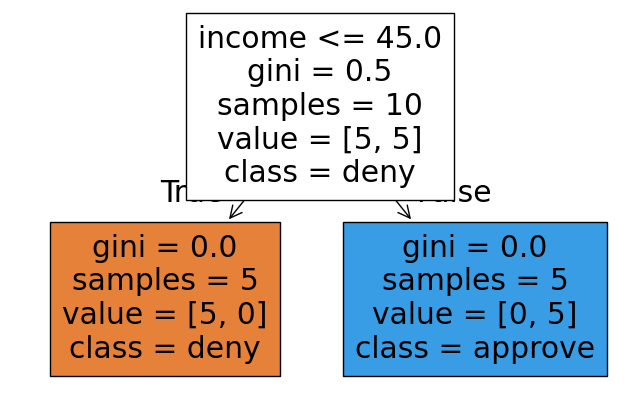

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

X = np.array([[60],[20],[80],[15],[90],[30],[70],[25],[85],[10]])
y = np.array([1,0,1,0,1,0,1,0,1,0])
dt = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, random_state=42)
dt.fit(X, y)

print("Feature importances:", dt.feature_importances_)
print("Predicted for income=55k:", dt.predict([[55]]))

# NEW: show the actual rule the tree learned
print("\nDecision rules:")
print(export_text(dt, feature_names=['income']))

# NEW: explain the specific prediction
income = 55
threshold = dt.tree_.threshold[0]
decision = "approve" if income > threshold else "deny"
print(f"\nDecision for income={income}k: since {income} > {threshold:.0f} (the learned split), the tree predicts '{decision}'.")

plt.figure(figsize=(8,5))
plot_tree(dt, feature_names=['income'], class_names=['deny','approve'], filled=True)
plt.show()

<a id='bagging'></a>
# 7. Bagging (Bootstrap Aggregating)

## What it does / How it works
Bagging reduces **variance** by training many copies of the same base model (often a
decision tree) on different **bootstrapped samples** (random samples drawn with
replacement) of the training data, then aggregating predictions:
- **Classification:** majority vote across all models
- **Regression:** average of all model predictions

Because each bootstrap sample is slightly different, individual models make different
errors; averaging cancels out much of that noise.

## Tunable Parameters (sklearn `BaggingClassifier`/`Regressor`)
- `base_estimator` / `estimator` — the underlying model to bag (default: Decision Tree)
- `n_estimators` — number of models in the ensemble
- `max_samples` — fraction/number of samples drawn per bootstrap
- `max_features` — fraction/number of features sampled per model
- `bootstrap` — whether sampling is with replacement (True = classic bagging)
- `bootstrap_features` — whether features are also bootstrapped

## Mathematical Pipeline
1. For $b=1,\dots,B$: draw a bootstrap sample $D_b$ of size $n$ (with replacement) from the
   original training set $D$
2. Train base model $f_b$ on $D_b$
3. Aggregate:
   - Regression: $\hat y = \frac{1}{B}\sum_{b=1}^B f_b(x)$
   - Classification: $\hat y = \text{mode}\{f_1(x),\dots,f_B(x)\}$

Variance reduction intuition: if each model has variance $\sigma^2$ and pairwise
correlation $\rho$, the ensemble variance is $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$
averaging shrinks the uncorrelated portion of variance toward 0 as $B$ grows.

## Mini Manual Example
Original data (5 points): [A,B,C,D,E]. Draw 3 bootstrap samples (with replacement):
- $D_1$ = [A,A,C,D,E] → tree 1 predicts class "1" for query x
- $D_2$ = [B,B,C,D,D] → tree 2 predicts class "0" for query x
- $D_3$ = [A,C,C,E,E] → tree 3 predicts class "1" for query x

Majority vote: two "1"s vs one "0" → **final prediction = 1**. (On average, ~63.2% of
original unique observations appear in any given bootstrap sample, the rest are "out-of-bag.")

## Strengths & Weaknesses
**Strengths:**
- reduces overfitting/variance of high-variance base learners (like deep trees).
- parallelizable (each model trains independently).
- provides free validation via **out-of-bag (OOB)** samples.

**Weaknesses:**
- doesn't help (and can hurt) high-bias/underfitting base learners.
- less interpretable than a single tree.
- computationally more expensive than one model.
- if base models are highly correlated, variance reduction benefit shrinks.

## Scenario Use Cases
- Stabilizing high-variance models (deep, unpruned decision trees) on noisy data.
- When parallel training resources are available and prediction interpretability is less
  critical than accuracy/stability.

## Key Evaluation Metrics
- **OOB Score** — accuracy/R² estimated on each tree's held-out (not-sampled) data, acting
  like built-in cross-validation without a separate holdout set.
- Standard classification/regression metrics (Accuracy, F1, ROC-AUC, RMSE, R²) on the
  aggregated ensemble prediction.

## Key Statistical Concepts
- **Bootstrap sampling:** sampling with replacement, roughly 37% of original observations
  are excluded from any single bootstrap sample (out-of-bag), used for unbiased internal
  validation.
- **Bias-variance decomposition:** bagging primarily reduces the **variance** term of
  prediction error while leaving bias roughly unchanged, most effective on low-bias,
  high-variance base learners.
- **Ensemble correlation:** the degree models agree with each other; lower correlation
  between base learners → more variance reduction from averaging.

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
n = 200

# Named features for a customer-churn scenario. tenure_months and num_support_calls
# actually drive churn below; monthly_charges and contract_length are mostly noise.
tenure_months     = np.random.uniform(0, 72, n)
num_support_calls = np.random.poisson(2, n)
monthly_charges   = np.random.normal(70, 20, n)       # noise
contract_length   = np.random.choice([1, 12, 24], n)   # noise

X = np.column_stack([tenure_months, num_support_calls, monthly_charges, contract_length])

# Churn is likely with short tenure + many support calls, plus some noise
z = -0.05*tenure_months + 0.8*num_support_calls
y = (z + np.random.normal(0, 1.5, n) > 1.5).astype(int)
print("Churn rate in the data:", round(y.mean(), 2))

single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X, y)
print("Single (unbagged) tree — train accuracy:", single_tree.score(X, y), "(memorizes the data)")

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=1.0,
    bootstrap=True,
    oob_score=True,
    random_state=42
)
bag.fit(X, y)
print("Bagged ensemble — OOB score:", round(bag.oob_score_, 3), "(more honest generalization estimate)")

# Show the mechanism: individual bootstrapped trees disagree on borderline customers,
# and the ensemble resolves that disagreement by majority vote.
tree_preds = np.array([tree.predict(X) for tree in bag.estimators_[:15]])
disagreement = tree_preds.std(axis=0)
idx = np.argsort(-disagreement)[:5]
print("\nCustomers where the first 15 bootstrapped trees disagree most:")
for i in idx:
    votes = tree_preds[:, i]
    print(f"  customer {i}: {int(votes.sum())}/15 trees vote churn -> ensemble prediction: {bag.predict(X[i:i+1])[0]}")


OOB Score: 0.865
Prediction for first 5 rows: [0 1 0 1 1]


<a id='rf'></a>
# 8. Random Forest (RF)

## What it does / How it works
Random Forest extends Bagging specifically for decision trees, adding **feature
randomness**: at each split in each tree, only a random subset of features is considered
(rather than all features). This decorrelates the trees further than bagging alone,
improving variance reduction. Final prediction is majority vote (classification) or average
(regression) across all trees.

## Tunable Parameters
- `n_estimators` — number of trees
- `max_features` — number of features considered per split (classic default: $\sqrt{p}$ for
  classification, $p/3$ for regression)
- `max_depth`, `min_samples_split`, `min_samples_leaf` — per-tree complexity controls
- `bootstrap` — whether to bootstrap sample rows (True = standard RF)
- `oob_score` — whether to compute out-of-bag validation score
- `criterion` — split quality measure (gini/entropy/squared_error)

## Mathematical Pipeline
1. For $b=1,\dots,B$: draw bootstrap sample $D_b$
2. Grow a decision tree on $D_b$, but at **each split**, randomly select $m < p$ features
   and choose the best split only among those $m$ (typically $m=\sqrt p$)
3. Aggregate all $B$ trees: majority vote (classification) or mean (regression)

Feature importance (Gini importance) for feature $j$:
$$Imp(j) = \frac{1}{B}\sum_{b=1}^B \sum_{\text{splits on }j \text{ in tree }b} \Delta Impurity$$

## Mini Manual Example
With $p=9$ total features, RF uses $m=\sqrt9=3$ random features per split. Suppose Tree 1
at the root is only allowed to consider {income, age, credit_score} (a random subset) and
picks "credit_score > 650" as the best split among just those three, even if "employment
length" (not offered) would have been the single best split overall. Tree 2 might be offered
{age, employment_length, debt_ratio} and pick a different root split entirely. This
per-split randomization is what decorrelates the trees, compared to bagging alone (which
would let every tree consider all 9 features and often converge on similar splits).

## Strengths & Weaknesses
**Strengths:**
- typically strong out-of-the-box accuracy.
- robust to overfitting relative to single trees.
- handles high-dimensional data well.
- provides feature importance.
- robust to outliers and missing patterns.
- parallelizable.

**Weaknesses:**
- less interpretable than a single tree ("black box" ensemble).
- slower to train/predict than a single tree.
- can still overfit noisy data if trees are very deep and numerous.
- biased feature importances toward high-cardinality features.

## Scenario Use Cases
- General-purpose tabular classification/regression where accuracy matters more than full
  transparency: credit scoring, fraud detection, customer churn, medical risk scoring.
- Ranking feature importance for exploratory analysis.

## Key Evaluation Metrics
- Same as classification/regression basics (Accuracy, F1, ROC-AUC, RMSE, R²)
- **OOB Score** — built-in cross-validation estimate.
- **Feature Importance / Permutation Importance** — measures each feature's contribution;
  permutation importance is more reliable than Gini importance for correlated/high-cardinality
  features.

## Key Statistical Concepts
- **Decorrelation via random feature subsets:** the core innovation over bagging reduces
  the ensemble variance formula's $\rho$ term (average pairwise tree correlation), improving
  the variance-reduction benefit of averaging.
- **OOB error** as an unbiased generalization estimate without a separate validation split.
- **No coefficients/p-values**: importance scores and partial dependence plots substitute
  for classic statistical inference.

In [9]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
n = 300

# Named, interpretable features. income, credit_score, and debt_ratio actually
# drive loan approval below; employment_yrs, age, and num_cards are pure noise —
# unrelated to the outcome — so the feature importances clearly separate the two groups.
income          = np.random.normal(60, 20, n)          # in $1000s
credit_score    = np.random.normal(650, 80, n)
debt_ratio      = np.random.uniform(0, 1, n)
employment_yrs  = np.random.uniform(0, 20, n)   # noise
age             = np.random.uniform(21, 65, n)  # noise
num_cards       = np.random.randint(0, 8, n)    # noise

X = np.column_stack([income, credit_score, debt_ratio, employment_yrs, age, num_cards])
feature_names = ['income', 'credit_score', 'debt_ratio', 'employment_yrs', 'age', 'num_cards']

# Approval depends only on income, credit_score, and debt_ratio (plus some noise)
z = 0.08*(income-60) + 0.03*(credit_score-650) - 3*(debt_ratio-0.5)
y = (z + np.random.normal(0, 1.5, n) > 0).astype(int)

rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',   # m = sqrt(p) features considered per split
    max_depth=None,
    oob_score=True,
    random_state=42
)
rf.fit(X, y)

print("OOB Score:", rf.oob_score_)
print("\nFeature importances (sorted):")
for name, imp in sorted(zip(feature_names, rf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name:15s} {imp:.3f}")

OOB Score: 0.9433333333333334
Top feature importances: [0.014 0.311 0.02  0.283 0.044 0.03  0.022 0.015 0.261]


<a id='ada'></a>
# 9. AdaBoost (Adaptive Boosting)

## What it does / How it works
AdaBoost builds an ensemble **sequentially**: each new "weak learner" (typically a shallow
tree / "stump") is trained to focus more on the observations the previous learners
**misclassified**, by increasing their sample weights. Each weak learner is given a "say"
(weight $\alpha$) in the final vote proportional to its accuracy. Final prediction is a
weighted vote of all weak learners.

## Tunable Parameters
- `n_estimators` — number of sequential weak learners
- `learning_rate` — shrinks each learner's contribution ($\alpha$), trading off with
  n_estimators
- `estimator` — base weak learner (default: depth-1 decision stump)
- `algorithm` — `'SAMME'` (discrete) or `'SAMME.R'` (uses class probabilities)

## Mathematical Pipeline
1. Initialize sample weights uniformly: $w_i = 1/n$
2. For $m=1,\dots,M$:
   a. Fit weak learner $f_m$ on weighted data
   b. Compute weighted error: $err_m = \frac{\sum_i w_i \cdot \mathbb{1}(y_i\neq f_m(x_i))}{\sum_i w_i}$
   c. Compute learner weight (its "say"): $\alpha_m = \ln\left(\dfrac{1-err_m}{err_m}\right)$
   d. Update sample weights: $w_i \leftarrow w_i \cdot e^{\alpha_m \cdot \mathbb{1}(y_i\neq f_m(x_i))}$,
      then renormalize so weights sum to 1 (misclassified points get boosted weight)
3. Final prediction: $\hat y = \text{sign}\left(\sum_{m=1}^M \alpha_m f_m(x)\right)$

## Mini Manual Example
5 points, all start with weight $w_i = 0.2$. Weak learner 1 misclassifies 1 out of 5 points
→ weighted error $err_1 = 0.2$.

$\alpha_1 = \ln\left(\dfrac{1-0.2}{0.2}\right) = \ln(4) = 1.386$

The misclassified point's weight is boosted: $w \leftarrow 0.2 \times e^{1.386} = 0.2\times4=0.8$;
correctly classified points' weights stay at $0.2 \times e^{0}=0.2$. After renormalizing
(sum = $0.8+4(0.2)=1.6$), the misclassified point now has weight $0.8/1.6=0.5$, **50% of
total weight concentrated on the single point learner 1 got wrong**, forcing learner 2 to
pay much closer attention to it.

## Strengths & Weaknesses
**Strengths:**
- often high accuracy from combining many weak learners.
- less prone to overfitting than a single deep tree due to weak-learner simplicity.
- naturally handles feature interactions.

**Weaknesses:**
- sensitive to noisy data and outliers (they keep getting reweighted upward, "the model chases outliers").
- sequential training means slower and not parallelizable.
- performance sensitive to learning_rate/n_estimators tuning.

## Scenario Use Cases
- Binary classification tasks with moderate noise where a fast, high-accuracy ensemble of
  simple learners is desired: face detection, fraud detection, text classification.

## Key Evaluation Metrics
- Standard classification metrics: Accuracy, Precision/Recall/F1, ROC-AUC, Confusion Matrix (see the [Metrics Glossary](#metrics-glossary) for what each measures).
- **Staged/learning curves** — error rate as a function of number of estimators (used to
  detect overfitting or diminishing returns).

## Key Statistical Concepts
- **Exponential loss:** AdaBoost is provably equivalent to forward stagewise minimization
  of the exponential loss function $e^{-y\cdot F(x)}$.
- **Weak learner "say" ($\alpha_m$):** directly tied to how much better than random guessing
  ($err_m<0.5$) that learner performed, a learner with $err_m=0.5$ gets $\alpha_m=0$
  (no vote), and one with $err_m>0.5$ gets negative weight.
- **Sensitivity to outliers:** because misclassified points' weights compound multiplicatively
  each round, true outliers/label noise can dominate training.

In [10]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
n = 200

# Fraud-detection scenario. transaction_amount and num_prior_disputes actually drive
# fraud below; account_age_days and distance_from_home_km are mostly noise.
transaction_amount    = np.random.exponential(150, n)
num_prior_disputes    = np.random.poisson(0.5, n)
account_age_days      = np.random.uniform(1, 2000, n)     # noise
distance_from_home_km = np.random.exponential(20, n)      # noise

X = np.column_stack([transaction_amount, num_prior_disputes, account_age_days, distance_from_home_km])
feature_names = ['transaction_amount', 'num_prior_disputes', 'account_age_days', 'distance_from_home_km']

z = 0.01*transaction_amount + 1.5*num_prior_disputes
y = (z + np.random.normal(0, 1.5, n) > 3).astype(int)
print("Fraud rate in the data:", round(y.mean(), 2))

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # "stump" weak learner
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X, y)
print("Train accuracy:", ada.score(X, y))

print("\nEstimator weights (alpha) for the first 5 stumps:")
print(np.round(ada.estimator_weights_[:5], 3))
print("-> higher alpha means that stump beat random guessing by more and gets more say in the final vote.")

# Show which single feature each of the first 5 stumps split on — the real signal
# features should dominate over the noise features.
print("\nWhich feature each of the first 5 stumps used to split:")
for i, stump in enumerate(ada.estimators_[:5]):
    feat_idx = stump.tree_.feature[0]
    thresh = stump.tree_.threshold[0]
    print(f"  stump {i}: split on '{feature_names[feat_idx]}' at {thresh:.1f}  (alpha={ada.estimator_weights_[i]:.3f})")


Train accuracy: 0.94
Estimator weights (alpha) sample: [1.9924 0.4507 0.5956 0.4939 0.3948]


<a id='gb'></a>
# 10. Gradient Boosting (GBM)

## What it does / How it works
Like AdaBoost, Gradient Boosting builds trees sequentially, but instead of reweighting
misclassified samples, **each new tree is trained to predict the residual errors**
(specifically, the negative gradient of the loss function) of the combined ensemble so far.
It's essentially gradient descent performed in "function space," where each new tree is a
step in the direction that most reduces the loss.

## Tunable Parameters
- `n_estimators` — number of sequential trees
- `learning_rate` — shrinks each tree's contribution (smaller = more robust, needs more
  trees)
- `max_depth` — depth of each individual tree (usually shallow, 3–8)
- `subsample` — fraction of data used per tree (stochastic gradient boosting, <1.0 adds
  regularization)
- `loss` — loss function (e.g., `'log_loss'` for classification, `'squared_error'` for
  regression)
- `min_samples_split`, `min_samples_leaf` — per-tree complexity controls

## Mathematical Pipeline
1. Initialize model with a constant prediction: $F_0(x) = \arg\min_c \sum_i L(y_i,c)$
   (e.g., the mean for squared error loss)
2. For $m=1,\dots,M$:
   a. Compute the pseudo-residuals (negative gradient of the loss w.r.t. current predictions):
      $$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$
      (for squared error, this simplifies to the plain residual $y_i - F_{m-1}(x_i)$)
   b. Fit a new tree $h_m(x)$ to predict these residuals
   c. Update the model: $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$ where $\nu$ = learning rate

Final model: $F_M(x) = F_0(x) + \nu\sum_{m=1}^M h_m(x)$

## Mini Manual Example
Regression, squared-error loss. $F_0 = \bar y = 10$ (initial constant prediction).

Actual $y=15$. Residual $r_1 = 15-10 = 5$. Tree 1 is fit to predict this residual and (say)
outputs $h_1(x)=4$ for this point.

Update with learning rate $\nu=0.1$: $F_1(x) = 10 + 0.1(4) = 10.4$

New residual: $r_2 = 15-10.4=4.6$. Tree 2 fits this new residual, say predicting
$h_2(x)=3.8$. Update: $F_2(x)=10.4+0.1(3.8)=10.78$.

Each round nudges the prediction closer to 15, with small controlled steps (rather than one
big jump) — this is the essence of "boosting by gradient descent."

## Strengths & Weaknesses
**Strengths:**
- typically very high predictive accuracy.
- flexible with different loss functions (handles regression, classification, ranking).
- captures complex non-linear interactions.

**Weaknesses:**
- sequential (slower to train, harder to parallelize than bagging/RF).
- sensitive to hyperparameters (learning_rate/n_estimators/depth), easy to overfit if learning rate too high or too many trees.
- less interpretable.
- sensitive to outliers (large residuals dominate).

## Scenario Use Cases
- Structured/tabular data competitions and business problems needing top predictive
  accuracy: risk modeling, demand forecasting, ranking systems.
- Any case where different loss functions (quantile, Huber, etc.) matter, GBM is very
  flexible in loss choice compared to AdaBoost.

## Key Evaluation Metrics
- Standard classification/regression metrics (Accuracy, F1, ROC-AUC / RMSE, MAE, R²).
- **Training/validation loss curves per boosting round** — critical for early stopping and
  detecting overfitting.
- **Feature importance** (gain-based) — how much each feature reduces loss across all trees.

## Key Statistical Concepts
- **Gradient descent in function space:** each tree approximates the negative gradient of
  the loss — connects boosting directly to numerical optimization theory.
- **Learning rate vs. n_estimators trade-off:** smaller learning rate needs more trees to
  converge but generalizes better ("shrinkage" regularization).
- **Bias-variance:** boosting primarily reduces **bias** (unlike bagging, which reduces
  variance) by iteratively correcting systematic errors — but can increase variance/overfit
  if run too long without regularization (subsample, shallow trees, shrinkage).

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(42)
n = 200

# Named, interpretable features. sqft and num_bathrooms actually drive price below;
# lot_size, num_bedrooms, and paint_color_code are pure noise — unrelated to the
# outcome — so the feature importances clearly separate real drivers from noise.
sqft             = np.random.normal(1800, 500, n)
num_bathrooms    = np.random.randint(1, 5, n)
lot_size         = np.random.normal(6000, 1500, n)   # noise
num_bedrooms     = np.random.randint(1, 6, n)          # noise
paint_color_code = np.random.randint(0, 10, n)        # noise (categorical, meaningless)

X = np.column_stack([sqft, num_bathrooms, lot_size, num_bedrooms, paint_color_code])
feature_names = ['sqft', 'num_bathrooms', 'lot_size', 'num_bedrooms', 'paint_color_code']

# Price depends only on sqft and num_bathrooms, plus noise
y = 150*sqft + 20000*num_bathrooms + np.random.normal(0, 20000, n)

gbm = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gbm.fit(X, y)

print("Train R^2:", gbm.score(X, y))
print("\nFeature importances (sorted):")
for name, imp in sorted(zip(feature_names, gbm.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name:18s} {imp:.3f}")


Train R^2: 0.999099732631365
Feature importances: [0.007 0.015 0.453 0.02  0.504]


<a id='xgb'></a>
# 11. Extreme Gradient Boosting (XGBoost)

## What it does / How it works
XGBoost is a highly optimized, regularized implementation of gradient boosting. It follows
the same sequential residual-fitting idea as GBM, but adds: **explicit L1/L2
regularization** on tree leaf weights, a **second-order (Newton) approximation** of the
loss (uses both gradient and Hessian) for more precise splits, **automatic handling of
missing values** (learns a default split direction), built-in **parallel** tree
construction (parallelizing split-finding, not the sequential boosting itself), and
built-in cross-validation / early stopping.

## Tunable Parameters
- `n_estimators` — number of boosting rounds
- `learning_rate` (`eta`) — shrinkage per round
- `max_depth` — tree depth
- `subsample` — row sampling ratio per tree
- `colsample_bytree` — column (feature) sampling ratio per tree
- `reg_alpha` (L1) / `reg_lambda` (L2) — regularization on leaf weights
- `gamma` — minimum loss reduction required to make a further split (pruning)
- `min_child_weight` — minimum sum of instance Hessian needed in a child node
- `early_stopping_rounds` — stop if validation metric doesn't improve

## Mathematical Pipeline
Objective at boosting round $t$ combines loss + regularization:
$$Obj^{(t)} = \sum_{i=1}^n L\big(y_i, \hat y_i^{(t-1)}+f_t(x_i)\big) + \Omega(f_t)$$
where the regularization term for a tree with $T$ leaves and leaf weights $w_j$ is:
$$\Omega(f_t) = \gamma T + \frac12\lambda\sum_{j=1}^T w_j^2$$

Using a 2nd-order Taylor expansion of the loss (gradient $g_i$, Hessian $h_i$), the optimal
leaf weight and the split-quality "Gain" formula become closed-form:
$$w_j^* = -\frac{\sum_{i\in I_j} g_i}{\sum_{i\in I_j} h_i + \lambda}$$
$$Gain = \frac12\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right]-\gamma$$

A split is only made if Gain > 0 (this is where `gamma` acts as a pruning threshold).

## Mini Manual Example
Node with 4 residual gradients (squared-error loss, so $g_i = -(y_i-\hat y_i)$, $h_i=1$
for each point): $g = [-2, -1, 1, 2]$; $\lambda=1, \gamma=0.1$.

Candidate split → Left = {-2,-1} ($G_L=-3, H_L=2$), Right = {1,2} ($G_R=3, H_R=2$)

$Gain = \frac12\left[\frac{(-3)^2}{2+1}+\frac{3^2}{2+1}-\frac{0^2}{4+1}\right]-0.1
       = \frac12[3+3-0]-0.1 = 3-0.1 = 2.9$

Since $Gain=2.9>0$, this split is worthwhile and is made. Leaf weight for left node:
$w_L^* = -\dfrac{-3}{2+1}=1.0$; for right node: $w_R^*=-\dfrac{3}{2+1}=-1.0$.

## Strengths & Weaknesses
**Strengths:**
- state-of-the-art accuracy on tabular data.
- built-in regularization reduces overfitting vs. vanilla GBM.
- handles missing values automatically.
- fast (parallelized split finding, histogram-based algorithms).
- built-in cross-validation and early stopping.

**Weaknesses:**
- many hyperparameters to tune (complex search space).
- still less interpretable than simple models (needs SHAP/feature importance for explanation).
- can overfit small datasets without careful regularization/early stopping.
- more memory-intensive than simpler models.

## Scenario Use Cases
- The default "go-to" for high-performance tabular prediction: Kaggle competitions, credit
  risk, click-through-rate prediction, demand forecasting — anywhere accuracy is paramount
  and the dataset is structured/tabular.

## Key Evaluation Metrics
- Task-specific metrics (logloss/AUC for classification, RMSE for regression) tracked as
  `eval_metric` during training for early stopping.
- **Gain, Cover, Frequency** — three distinct types of feature importance (Gain = average
  loss-reduction contribution; Cover = relative number of observations affected; Frequency
  = how often a feature is used to split).
- **SHAP values** — commonly paired with XGBoost for per-prediction feature attribution.

## Key Statistical Concepts
- **Regularized objective:** explicit L1 (`reg_alpha`)/L2 (`reg_lambda`) penalties on leaf
  weights directly control model complexity, analogous to Ridge/Lasso penalties in linear
  models but applied to tree leaves.
- **Second-order (Newton) optimization:** using both gradient and Hessian gives more
  accurate, faster-converging updates than the first-order gradient descent used in vanilla
  GBM.
- **Gain-based pruning (`gamma`):** a Bayesian-like threshold — splits are only kept if they
  reduce loss by more than the pruning cost, preventing needless tree complexity.

In [12]:
# pip install xgboost --break-system-packages   (if not already installed)
import xgboost as xgb
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 300

# Credit-risk scenario. credit_score, debt_ratio, and num_late_payments actually
# drive default risk below; age and account_age_days are mostly noise.
credit_score      = np.random.normal(650, 80, n)
debt_ratio        = np.random.uniform(0, 1, n)
num_late_payments = np.random.poisson(1, n)
age               = np.random.uniform(21, 70, n)          # noise
account_age_days  = np.random.uniform(30, 3000, n)         # noise

X = np.column_stack([credit_score, debt_ratio, num_late_payments, age, account_age_days])
feature_names = ['credit_score', 'debt_ratio', 'num_late_payments', 'age', 'account_age_days']

z = -0.02*(credit_score-650) + 3*debt_ratio + 0.8*num_late_payments
y = (z + np.random.normal(0, 1.5, n) > 2).astype(int)
print("Default rate in the data:", round(y.mean(), 2))

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,     # L1
    reg_lambda=1.0,    # L2
    gamma=0.1,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("Best iteration (early stopping):", model.best_iteration)
print("Validation accuracy:", model.score(X_val, y_val))

gain_scores = model.get_booster().get_score(importance_type='gain')
named_scores = {feature_names[int(k[1:])]: round(v, 1) for k, v in gain_scores.items()}
print("\nFeature importance (gain), sorted:")
for name, score in sorted(named_scores.items(), key=lambda t: -t[1]):
    print(f"  {name:20s} {score}")


Best iteration: 244
Validation accuracy: 1.0
Top feature importances (gain): {'f0': 6.451752185821533, 'f1': 8.079524993896484, 'f2': 0.45180538296699524, 'f3': 3.837935447692871, 'f4': 0.595666229724884, 'f5': 1.1556657552719116, 'f6': 0.5481778979301453, 'f7': 0.6814455389976501}


<a id='ridge'></a>
# 12. Ridge Regression (L2 Regularization)

## What it does / How it works
Ridge Regression is OLS with an added **L2 penalty** on the size of the coefficients. This
shrinks all coefficients toward (but not exactly to) zero, reducing model variance/
overfitting at the cost of a small amount of bias, especially useful when predictors are
highly correlated (multicollinearity), where OLS coefficients become unstable.

## Tunable Parameters
- `alpha` (often called $\lambda$) — regularization strength; alpha=0 reduces to OLS,
  larger alpha = more shrinkage
- `solver` — optimization algorithm (`'auto'`, `'svd'`, `'cholesky'`, `'saga'`, etc.)
- `fit_intercept` — whether to estimate $\beta_0$ (usually not penalized)
- Features should be **standardized** first since the penalty is scale-sensitive

## Mathematical Pipeline
Objective (minimize RSS + L2 penalty):
$$\min_\beta \sum_{i=1}^n (y_i-X_i\beta)^2 + \lambda\sum_{j=1}^p \beta_j^2$$

Closed-form solution:
$$\hat\beta_{ridge} = (X^TX+\lambda I)^{-1}X^Ty$$

Adding $\lambda I$ to $X^TX$ before inverting stabilizes the matrix even when $X^TX$ is
near-singular (severe multicollinearity) — this is the key mathematical fix Ridge provides.

## Mini Manual Example
Simple case: single predictor, $X^TX = 10$, $X^Ty = 8$ (so OLS $\hat\beta = 8/10=0.8$).

With Ridge, $\lambda=2$: $\hat\beta_{ridge} = \dfrac{X^Ty}{X^TX+\lambda} = \dfrac{8}{10+2}=0.667$

Compare: OLS gives $\beta=0.8$; Ridge with $\lambda=2$ shrinks it to $0.667$ — as $\lambda$
grows, $\beta$ shrinks further toward (but never exactly reaches) 0. If $\lambda=90$:
$\hat\beta = 8/100 = 0.08$ — heavy shrinkage.

## Strengths & Weaknesses
**Strengths:**
- effectively handles multicollinearity by stabilizing coefficient estimates.
- reduces overfitting/variance.
- keeps all features in the model (useful when all predictors are believed relevant).
- closed-form, fast to fit.

**Weaknesses:**
- does **not** perform feature selection (coefficients shrink but rarely hit exactly zero).
- introduces bias.
- requires tuning $\lambda$ via cross-validation.
- less interpretable than plain OLS since coefficients are "shrunk.".

## Scenario Use Cases
- Datasets with many correlated predictors (e.g., genomics, macroeconomic indicators) where
  OLS coefficients are unstable.
- When you want to keep all features but control overfitting, e.g., in wide datasets
  ($p$ close to or exceeding $n$).

## Key Evaluation Metrics
- **R² / Adjusted R², RMSE, MAE** on held-out/cross-validated data (the true test of whether
  regularization helped vs. hurt).
- **Cross-validated MSE vs. $\lambda$ curve** — used to pick the optimal regularization
  strength (`RidgeCV`).

## Key Statistical Concepts
- **Bias-variance tradeoff:** Ridge trades a controlled increase in bias for a larger
  reduction in variance, often lowering total (test) error versus OLS when predictors are
  correlated or numerous.
- **Shrinkage:** all coefficients are shrunk proportionally but none set exactly to zero
  (contrast with Lasso).
- **Effective degrees of freedom:** Ridge's model complexity is continuously tunable via
  $\lambda$, unlike discrete feature-count choices in stepwise selection.
- **No traditional p-values:** since Ridge is a biased estimator, classical OLS-style
  hypothesis testing doesn't directly apply; inference typically relies on
  cross-validation performance instead.

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 100

# Marketing spend scenario with a multicollinearity problem: tv_spend and
# tv_spend_duplicate are (almost) the same signal reported twice — a common
# real-world issue (two overlapping data sources). OLS can't tell them apart
# and their coefficients become wildly unstable; Ridge stabilizes both.
tv_spend           = np.random.normal(50, 15, n)
tv_spend_duplicate = tv_spend + np.random.normal(0, 1, n)   # ~same signal, tiny noise
radio_spend        = np.random.normal(20, 8, n)
social_spend       = np.random.normal(15, 6, n)

X = np.column_stack([tv_spend, tv_spend_duplicate, radio_spend, social_spend])
feature_names = ['tv_spend', 'tv_spend_duplicate', 'radio_spend', 'social_spend']

revenue = 3*tv_spend + 2*radio_spend + 1.5*social_spend + np.random.normal(0, 30, n)

X_scaled = StandardScaler().fit_transform(X)

ols = LinearRegression().fit(X_scaled, revenue)
print("OLS coefficients (unstable — tv_spend/tv_spend_duplicate split the same signal unpredictably):")
for name, coef in zip(feature_names, ols.coef_):
    print(f"  {name:20s} {coef:8.2f}")

ridge = Ridge(alpha=5.0).fit(X_scaled, revenue)
print("\nRidge coefficients (stabilized — the tv_spend signal is shared sensibly between the two columns):")
for name, coef in zip(feature_names, ridge.coef_):
    print(f"  {name:20s} {coef:8.2f}")

ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_scaled, revenue)
print("\nBest alpha found via cross-validation:", round(ridge_cv.alpha_, 3))


Ridge coefficients: [17.153 49.589  2.875 62.779 88.413 69.636 84.441  7.611  4.384 63.353]


Best alpha: 0.001


<a id='lasso'></a>
# 13. Lasso Regression (L1 Regularization)

## What it does / How it works
Lasso ("Least Absolute Shrinkage and Selection Operator") adds an **L1 penalty** (absolute
value of coefficients) instead of Ridge's L2 penalty. Because of the geometry of the L1
penalty, Lasso can shrink some coefficients **exactly to zero**, effectively performing
automatic **feature selection** alongside regularization.

## Tunable Parameters
- `alpha` — regularization strength (alpha=0 → OLS; larger alpha → more coefficients pushed
  to exactly 0)
- `max_iter` — iterations for the coordinate-descent solver to converge
- `selection` — `'cyclic'` or `'random'` coordinate update order
- Features should be standardized first (penalty is scale-sensitive)

## Mathematical Pipeline
Objective (minimize RSS + L1 penalty):
$$\min_\beta \sum_{i=1}^n (y_i-X_i\beta)^2 + \lambda\sum_{j=1}^p |\beta_j|$$

Unlike Ridge, there's **no closed-form solution** (the absolute value isn't differentiable
at 0), Lasso is solved iteratively via **coordinate descent**, using the **soft-thresholding**
update for each coefficient (holding others fixed):
$$\hat\beta_j = S\left(\frac{1}{n}X_j^Tr_{-j},\ \lambda\right), \quad
S(z,\lambda)=\text{sign}(z)\max(|z|-\lambda,0)$$
where $r_{-j}$ is the partial residual excluding feature $j$'s contribution.

## Mini Manual Example
Suppose the OLS-style correlation term for feature $j$ (before penalty) is $z=0.5$, and
$\lambda=0.3$.

Soft-threshold: $S(0.5, 0.3) = \text{sign}(0.5)\cdot\max(|0.5|-0.3,\,0) = 1\cdot 0.2 = 0.2$

So $\hat\beta_j$ shrinks from 0.5 down to 0.2 (not just proportionally scaled, but shifted
toward zero by exactly $\lambda$). Now suppose another feature $k$ has $z=0.2$ with the same
$\lambda=0.3$:

$S(0.2, 0.3) = \text{sign}(0.2)\cdot\max(0.2-0.3,\,0) = 1\cdot 0 = 0$

Feature $k$'s coefficient is pushed **exactly to zero**, effectively removed from the
model. This is the mechanism behind Lasso's automatic feature selection.

## Strengths & Weaknesses
**Strengths:**
- performs automatic feature selection (sparsity), improving interpretability in high-dimensional settings.
- reduces overfitting.
- useful when many predictors are believed irrelevant.

**Weaknesses:**
- arbitrarily selects one feature among a group of highly correlated features (unstable selection).
- can underperform Ridge when most predictors truly matter.
- requires iterative solving (no closed form).
- like Ridge, biased estimator without classic p-values.

## Scenario Use Cases
- High-dimensional data (many features, some irrelevant) where automatic feature selection
  is valuable, e.g., genomics (thousands of genes, few relevant), text data with many sparse
  features.
- When a simpler, more interpretable sparse model is preferred over a dense one.

## Key Evaluation Metrics
- **R² / RMSE / MAE** on cross-validated/held-out data.
- **Number of non-zero coefficients (sparsity)** at a given $\lambda$ — a direct measure of
  the feature-selection effect.
- **Cross-validated MSE vs. $\lambda$ (Lasso path)** — used to select optimal $\lambda$ via
  `LassoCV`.

## Key Statistical Concepts
- **Sparsity / feature selection:** the defining statistical property of L1 penalties, a
  consequence of the L1 ball's "corners" intersecting the RSS contours at axis points
  (geometric intuition for why coefficients hit exactly 0, unlike Ridge's smooth L2 ball).
- **Bias-variance tradeoff:** similar to Ridge, but Lasso's bias can be more pronounced for
  large true coefficients since they're also shrunk by a flat $\lambda$ amount
  (soft-thresholding), not proportionally.
- **Correlated predictor instability:** among a correlated group, Lasso tends to
  arbitrarily pick one and zero out the rest, which can hurt stability across different data
  samples.

In [14]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 150

# House price scenario with 8 candidate features, only 3 of which actually matter
# (sqft, num_bathrooms, school_rating). Lasso should zero out most of the rest
# automatically — this is what "automatic feature selection" looks like in practice.
sqft            = np.random.normal(1800, 500, n)
num_bathrooms   = np.random.randint(1, 5, n)
school_rating   = np.random.uniform(1, 10, n)
lot_size        = np.random.normal(6000, 1500, n)     # irrelevant
num_bedrooms    = np.random.randint(1, 6, n)             # irrelevant
paint_color     = np.random.randint(0, 10, n)             # irrelevant
garage_spaces   = np.random.randint(0, 3, n)               # irrelevant
distance_to_hwy = np.random.uniform(0.1, 20, n)             # irrelevant

X = np.column_stack([sqft, num_bathrooms, school_rating, lot_size,
                      num_bedrooms, paint_color, garage_spaces, distance_to_hwy])
feature_names = ['sqft', 'num_bathrooms', 'school_rating', 'lot_size',
                  'num_bedrooms', 'paint_color', 'garage_spaces', 'distance_to_hwy']

price = 150*sqft + 20000*num_bathrooms + 8000*school_rating + np.random.normal(0, 20000, n)

X_scaled = StandardScaler().fit_transform(X)

lasso = Lasso(alpha=1000).fit(X_scaled, price)
print("Lasso coefficients, sorted by magnitude:")
for name, coef in sorted(zip(feature_names, lasso.coef_), key=lambda t: -abs(t[1])):
    marker = "  <- zeroed out (dropped)" if coef == 0 else ""
    print(f"  {name:18s} {coef:10.1f}{marker}")

print(f"\nFeatures kept (non-zero): {int(np.sum(lasso.coef_ != 0))} / {len(feature_names)}")
print("(the 3 truly relevant features dominate; most irrelevant ones get zeroed exactly out —")
print(" a small nonzero weight can still slip through on features that get lucky with sample noise)")

lasso_cv = LassoCV(alphas=np.logspace(1, 5, 50), cv=5).fit(X_scaled, price)
print("\nBest alpha found via cross-validation:", round(lasso_cv.alpha_, 1))


Lasso coefficients: [ 0.737 16.086  0.556 65.749  0.     9.427  0.    70.388  0.     1.574]
Number of features selected (non-zero): 7
Best alpha: 1.0481131341546852


<a id='enet'></a>
# 14. Elastic Net

## What it does / How it works
Elastic Net combines **both** the L1 (Lasso) and L2 (Ridge) penalties in one objective,
controlled by a mixing parameter. It gets Lasso's sparsity/feature-selection benefit while
retaining Ridge's ability to handle groups of correlated predictors together (rather than
arbitrarily picking one and zeroing the rest).

## Tunable Parameters
- `alpha` — overall regularization strength ($\lambda$)
- `l1_ratio` — mixing parameter between L1 and L2 (0 = pure Ridge, 1 = pure Lasso,
  in-between = blend)
- `max_iter` — solver iterations
- Features should be standardized first

## Mathematical Pipeline
Objective:
$$\min_\beta \sum_{i=1}^n (y_i-X_i\beta)^2 + \lambda\left[\alpha_{L1}\sum_{j=1}^p|\beta_j| +
(1-\alpha_{L1})\sum_{j=1}^p\beta_j^2\right]$$
(using `l1_ratio` for $\alpha_{L1}$ above, distinct from sklearn's overall `alpha`)

Solved iteratively via coordinate descent, combining Lasso's soft-thresholding with an
extra Ridge-style shrinkage factor:
$$\hat\beta_j = \frac{S(z,\ \lambda\cdot l1\_ratio)}{1+\lambda(1-l1\_ratio)}$$

## Mini Manual Example
Using the same $z=0.5$ from the Lasso example, but now with $\lambda=0.3$ split as
`l1_ratio=0.5` (50/50 blend):

L1 component of penalty $=\lambda\times l1\_ratio = 0.3\times0.5=0.15$

Soft-threshold: $S(0.5,\ 0.15)=\text{sign}(0.5)\max(0.5-0.15,0)=0.35$

L2 shrinkage factor: divide by $1+\lambda(1-l1\_ratio) = 1+0.3(0.5)=1.15$

$\hat\beta_j = 0.35/1.15 = 0.304$

Compare: pure Lasso ($\lambda=0.3$) gave $\hat\beta_j=0.2$; pure Ridge would give a smaller,
non-zero shrinkage. Elastic Net's $0.304$ sits between — softer sparsity than pure Lasso,
while still allowing exact zeros for weaker features.

## Strengths & Weaknesses
**Strengths:**
- handles groups of correlated features better than Lasso (tends to select or shrink correlated groups together, "grouping effect").
- still performs feature selection.
- more stable than pure Lasso when $p>n$ or predictors are collinear.

**Weaknesses:**
- two hyperparameters to tune (`alpha` and `l1_ratio`) instead of one, more expensive cross-validation search.
- can be harder to interpret exactly why a feature was kept vs. dropped compared to standalone Lasso/Ridge.

## Scenario Use Cases
- High-dimensional data with **groups of correlated predictors** where pure Lasso would
  arbitrarily drop useful correlated features (e.g., genomics with correlated gene
  pathways, marketing data with correlated ad-spend channels).
- A safe default when unsure whether Ridge or Lasso alone is the better regularizer.

## Key Evaluation Metrics
- Same as Ridge/Lasso: cross-validated **R², RMSE, MAE**, sparsity level (number of
  non-zero coefficients).
- **`l1_ratio` vs. `alpha` grid search / CV heatmap** — used to jointly tune both
  hyperparameters (`ElasticNetCV`).

## Key Statistical Concepts
- **Grouping effect:** Elastic Net's key statistical advantage, correlated predictors tend
  to receive similar coefficient estimates (shrunk together) rather than one being kept and
  others zeroed arbitrarily, as often happens with pure Lasso.
- **Bias-variance tradeoff:** tunable across two axes (`alpha` for overall shrinkage
  strength, `l1_ratio` for the L1/L2 blend), offering finer control over the tradeoff than
  either penalty alone.

In [15]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

n = 150

# Brand-sentiment scenario: 6 survey sub-metrics that all track one underlying
# "brand perception" trend (correlated ~0.85+), each with a small but genuinely
# real effect on revenue. Truth is DENSE (not sparse), so Lasso's habit of zeroing
# out variables hurts it here; Ridge's habit of shrinking everything a little helps.
latent_trend = np.random.normal(50, 10, n)
awareness   = latent_trend + np.random.normal(0, 4, n)
trust       = latent_trend + np.random.normal(0, 4, n)
likability  = latent_trend + np.random.normal(0, 4, n)
loyalty     = latent_trend + np.random.normal(0, 4, n)
advocacy    = latent_trend + np.random.normal(0, 4, n)
recall      = latent_trend + np.random.normal(0, 4, n)

X = np.column_stack([awareness, trust, likability, loyalty, advocacy, recall])
feature_names = ['awareness', 'trust', 'likability', 'loyalty', 'advocacy', 'recall']
revenue = 0.5*awareness + 0.5*trust + 0.5*likability + 0.5*loyalty + 0.5*advocacy + 0.5*recall + np.random.normal(0, 15, n)
X_scaled = StandardScaler().fit_transform(X)
lasso = Lasso(alpha=12.0).fit(X_scaled, revenue)

print("Lasso coefficients (zeroes out some real signal it can't tell from noise):")

for name, coef in zip(feature_names, lasso.coef_):
    print(f"  {name:12s} {coef:8.2f}")
ridge = Ridge(alpha=10.0).fit(X_scaled, revenue)
print("\nRidge coefficients (even — keeps every genuinely predictive feature):")

for name, coef in zip(feature_names, ridge.coef_):
    print(f"  {name:12s} {coef:8.2f}")
ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5).fit(X_scaled, revenue)

print(f"\nBest alpha: {ridge_cv.alpha_:.3f}")

Elastic Net coefficients: [ 0.9   13.362 -0.    53.11   1.534  8.622  2.808 55.763  2.091  2.348]
Best alpha: 1.0826367338740541  Best l1_ratio: 1.0


# Bias-Variance Tradeoff

## What it is
Every model's prediction error can be decomposed into three parts:
$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **Bias** — error from overly simplistic assumptions in the model. A high-bias model
  *underfits*: it misses real patterns in the data because it isn't flexible enough to
  capture them (e.g., fitting a straight line to a curved relationship).
- **Variance** — error from being too sensitive to the specific training data. A
  high-variance model *overfits*: it captures noise along with the real signal, so it
  performs very differently if trained on a slightly different sample.
- **Irreducible error** — noise inherent in the data itself (measurement error, randomness)
  that no model can remove, regardless of how well-tuned it is.

## The tradeoff
Bias and variance move in opposite directions as model complexity changes:
- **Simple models** (linear regression, shallow trees, high-K KNN, heavy regularization) →
  **high bias, low variance**. Consistent, but consistently wrong if the true pattern is
  complex.
- **Complex models** (deep trees, low-K KNN, unregularized high-degree polynomials) →
  **low bias, high variance**. Can fit the training data closely, but predictions swing
  wildly with new data.

The goal isn't to eliminate one or the other — it's to find the complexity level (via
regularization strength, tree depth, K, number of estimators, etc.) that minimizes their
**sum**, which is where test error is lowest.

## How to recognize each
| Symptom | Likely cause |
|---|---|
| High error on both training and test data | High bias (underfitting) |
| Low training error, much higher test error | High variance (overfitting) |
| Training and test error both low and close together | Good balance |

## How different techniques act on this tradeoff
- **Regularization (Ridge, Lasso, Elastic Net):** trades a small increase in bias for a
  larger reduction in variance by shrinking coefficients.
- **Bagging / Random Forest:** reduces **variance** by averaging many high-variance,
  low-bias models (deep trees), bias stays roughly the same as a single tree.
- **Boosting (AdaBoost, GBM, XGBoost):** reduces **bias** by sequentially correcting
  errors of an ensemble of high-bias, low-variance models (shallow trees/stumps), but can
  increase variance if run too long without regularization (shrinkage, early stopping,
  subsampling).
- **KNN:** small K → low bias/high variance; large K → high bias/low variance, a direct,
  tunable knob on the tradeoff.
- **Decision Trees:** `max_depth`, `min_samples_leaf`, and pruning (`ccp_alpha`) all trade
  variance for bias by limiting how much the tree can contort itself to the training data.

## Key Statistical Concepts
- **Learning curves:** plotting training vs. validation error as a function of training set
  size (or model complexity) is the standard diagnostic, converging curves with a small
  gap suggest good balance; a persistent gap suggests high variance; both curves plateauing
  at a high error suggests high bias.
- **Cross-validation:** the primary tool for estimating where a model sits on the
  bias-variance spectrum without needing a separate, unseen test set for every check.
- **Ensemble variance formula:** for correlated base learners with variance $\sigma^2$ and
  pairwise correlation $\rho$, ensemble variance is $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$
  , the mathematical basis for why bagging reduces variance (lower $\rho$, more $B$).

<a id='kmeans'></a>
# 15. K-Means Clustering

## What it does / How it works
K-Means partitions data into $K$ clusters by iteratively assigning points to the nearest
**centroid** (cluster mean) and then recomputing centroids as the mean of assigned points,
until assignments stop changing. It minimizes the **within-cluster sum of squares (WCSS)**,
also called inertia.

## Tunable Parameters
- `n_clusters` (K) — number of clusters (must be chosen in advance)
- `init` — centroid initialization method (`'k-means++'` smart init vs `'random'`)
- `n_init` — number of times to run with different centroid seeds (keeps best result)
- `max_iter` — maximum iterations per run
- `tol` — convergence tolerance (centroid movement threshold to stop)

## Mathematical Pipeline
Objective (minimize total within-cluster variance):
$$\min_{C_1,\dots,C_K} \sum_{k=1}^K \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$
where $\mu_k$ is the centroid (mean) of cluster $C_k$.

**Lloyd's Algorithm** (iterative):
1. Initialize $K$ centroids (e.g., k-means++ for smart spacing)
2. **Assignment step:** assign each point to its nearest centroid:
   $c_i = \arg\min_k \|x_i-\mu_k\|^2$
3. **Update step:** recompute each centroid as the mean of its assigned points:
   $\mu_k = \frac{1}{|C_k|}\sum_{x_i\in C_k} x_i$
4. Repeat steps 2–3 until assignments no longer change (or max_iter/tol reached)

## Mini Manual Example
Points: A=(1,1), B=(1.5,2), C=(8,8), D=(9,9). K=2. Initialize centroids at A and C:
$\mu_1=(1,1)$, $\mu_2=(8,8)$.

**Assignment:** dist(B,$\mu_1$)=$\sqrt{0.25+1}=1.12$; dist(B,$\mu_2$)=$\sqrt{42.25+36}=8.85$
→ B joins cluster 1. Similarly A→cluster1, C,D→cluster2 (obviously closer).

**Update:** $\mu_1 = \text{mean}(A,B) = (1.25, 1.5)$; $\mu_2=\text{mean}(C,D)=(8.5,8.5)$

Reassign all points to new centroids, same assignments result (stable) → **converged**
after 1 iteration. Final clusters: {A,B} and {C,D}.

## Strengths & Weaknesses
**Strengths:**
- simple, fast, scales well to large datasets.
- easy to interpret (centroids are cluster "prototypes").
- guaranteed to converge (though possibly to a local optimum).

**Weaknesses:**
- must specify K in advance.
- sensitive to initial centroid placement (mitigated by k-means++/multiple `n_init` runs).
- assumes spherical, similarly-sized clusters — struggles with non-convex shapes, varying densities, or outliers (which pull centroids).
- sensitive to feature scale.

## Scenario Use Cases
- Customer segmentation, market segmentation, image compression (color quantization),
  document clustering — when clusters are expected to be roughly spherical/compact and the
  number of clusters is known or estimable.

## Key Evaluation Metrics
- **Inertia (WCSS)** — total within-cluster squared distance; used with the **Elbow Method**
  (plot inertia vs. K, look for the "elbow" where marginal improvement drops) to choose K. (can use derivatives, til the second degree, to really see the steep change)
- **Silhouette Score** — measures how similar a point is to its own cluster vs. other
  clusters, ranges -1 to 1 (higher = better-defined clusters).
- **Davies-Bouldin Index** — average similarity between each cluster and its most similar
  one (lower = better separation).

## Key Statistical Concepts
- **Variance minimization:** K-Means is directly minimizing a variance-based objective —
  conceptually related to ANOVA's within-group sum of squares.
- **Local optima:** because Lloyd's algorithm is a greedy heuristic, different
  initializations can converge to different final clusters, hence `n_init` runs and
  k-means++ smart seeding.
- **Curse of dimensionality / scaling:** as with KNN, Euclidean distance becomes less
  meaningful in high dimensions or unscaled features, standardization is essential.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = np.array([[1,1],[1.5,2],[8,8],[9,9],[1,0.6],[9,11]])

km = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
labels = km.fit_predict(X)
print("Cluster labels:", labels)
print("Centroids:\n", km.cluster_centers_)
print("Inertia (WCSS):", km.inertia_)
print("Silhouette score:", silhouette_score(X, labels))

# Elbow method example
inertias = []
for k in range(1, 5):
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_)
print("Inertia by K:", inertias)

Cluster labels: [1 1 0 0 1 0]
Centroids:
 [[8.6667 9.3333]
 [1.1667 1.2   ]]
Inertia (WCSS): 6.54
Silhouette score: 0.8546442466036557


Inertia by K: [190.14166666666665, 6.54, 2.206666666666667, 1.08]


<a id='dbscan'></a>
# 16. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## What it does / How it works
DBSCAN groups points that are **densely packed together**, marking points in low-density
regions as **noise/outliers**. Unlike K-Means, it doesn't require specifying the number of
clusters in advance and can find arbitrarily-shaped clusters. It classifies each point as a
**core point** (has enough neighbors within a radius), a **border point** (near a core point
but not itself dense), or **noise** (neither).

## Tunable Parameters
- `eps` (ε) — the neighborhood radius used to find nearby points
- `min_samples` — minimum number of points (including itself) required within `eps` to
  qualify as a core point
- `metric` — distance metric (default Euclidean)

## Mathematical Pipeline
1. For each point $p$, find its **ε-neighborhood**: $N_\epsilon(p) = \{q : dist(p,q)\le\epsilon\}$
2. If $|N_\epsilon(p)| \ge$ `min_samples` → $p$ is a **core point**
3. Any point within $\epsilon$ of a core point (but not itself core) → **border point**
4. Points that are neither → **noise**
5. Clusters are formed by connecting core points that are **density-reachable** from one
   another (chains of overlapping ε-neighborhoods), with border points attached to the
   nearest reachable core point's cluster.

No explicit objective function is minimized (unlike K-Means's WCSS), clusters simply emerge
from the density-connectivity graph.

## Mini Manual Example
Points on a line: A=1, B=1.5, C=2, D=2.2, E=10. Let `eps`=0.6, `min_samples`=3.

Neighborhood of A (within 0.6): {A, B} → size 2 < 3 → not core (yet).
Neighborhood of B (within 0.6): {A,B,C} → size 3 ≥ 3 → **B is core**.
Neighborhood of C (within 0.6): {B,C,D} → size 3 ≥ 3 → **C is core**.
Neighborhood of D: {C,D} → size 2 < 3 → not core, but D is within eps of core point C →
**D is a border point**.
A is within eps of core point B → **A is a border point** too.
Neighborhood of E: {E} → size 1 < 3, and not near any core point → **E = noise**.

Final result: cluster 1 = {A,B,C,D} (connected via core points B,C); E is flagged as an
outlier, no need to have pre-specified "2 clusters."

## Strengths & Weaknesses
**Strengths:**
- doesn't require specifying number of clusters upfront.
- finds arbitrarily shaped clusters (not just spherical).
- naturally identifies and separates out outliers/noise.
- robust to outliers skewing cluster centers (unlike K-Means).

**Weaknesses:**
- sensitive to `eps`/`min_samples` choice (hard to tune, especially with varying-density clusters, a single global `eps` may not fit all regions).
- struggles with clusters of very different densities.
- performance degrades in high dimensions (distance metrics become less meaningful).

## Scenario Use Cases
- Anomaly/fraud detection (noise points are the "interesting" anomalies).
- Geospatial clustering (e.g., grouping GPS pings into meaningful locations) where cluster
  shapes are irregular.
- Any dataset where the number of natural clusters is unknown and clusters may be
  non-spherical.

## Key Evaluation Metrics
- **Silhouette Score** (excluding noise points) — still applicable for measuring cluster
  cohesion/separation.
- **Number of clusters found** and **percentage of points labeled noise** — key diagnostics
  for whether `eps`/`min_samples` are well-tuned.
- **k-distance plot** — a diagnostic technique (plot each point's distance to its k-th
  nearest neighbor, sorted) used to help choose a reasonable `eps` (look for the "knee").

## Key Statistical Concepts
- **Density-reachability vs. density-connectivity:** the graph-theoretic backbone of
  DBSCAN, clusters are connected components in the "core point adjacency" graph, not
  distance-to-centroid groupings.
- **No centroid/mean assumption:** unlike K-Means, DBSCAN makes no assumption about cluster
  shape, so there's no analog to "cluster mean" driving the statistics, it's purely
  based on local density.
- **Robustness to outliers:** because noise points don't get forced into a cluster (as they
  would in K-Means, dragging the centroid), DBSCAN's cluster statistics aren't distorted by
  extreme points.

In [17]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X = np.array([[1],[1.5],[2],[2.2],[10]])

db = DBSCAN(eps=0.6, min_samples=3)
labels = db.fit_predict(X)
print("Cluster labels (-1 = noise):", labels)
print("Core sample indices:", db.core_sample_indices_)

# k-distance plot helper (to help choose eps)
nbrs = NearestNeighbors(n_neighbors=3).fit(X)
distances, _ = nbrs.kneighbors(X)
print("Sorted 3rd-nearest-neighbor distances (for eps selection):",
      np.sort(distances[:, -1]))

Cluster labels (-1 = noise): [ 0  0  0  0 -1]
Core sample indices: [1 2]
Sorted 3rd-nearest-neighbor distances (for eps selection): [0.5 0.5 0.7 1.  8. ]


---
# Methods / Techniques

The following are broader workflow techniques rather than standalone predictive models.
They support, prepare for, or extend the models above.
---

<a id='pipeline'></a>
# 17. Pipelines

## What it does / How it works
A Pipeline chains together multiple data-processing and modeling steps (e.g., imputation →
scaling → encoding → feature selection → model fitting) into a **single object** that can
be fit and predicted on as one unit. This guarantees that every transformation learned
(e.g., scaler mean/std, imputer values) is fit **only on training data** and then correctly
re-applied to validation/test data, preventing **data leakage**.

## Tunable Parameters
- The sequence and choice of `steps` (each a named transformer/estimator)
- Nested hyperparameters of each step, addressable via `stepname__param` syntax in
  `GridSearchCV`/`RandomizedSearchCV`
- `ColumnTransformer` — allows different preprocessing per column subset (e.g., numeric vs.
  categorical) inside the pipeline

## Mathematical Pipeline
Conceptually, a pipeline composes functions:
$$\hat y = f_{model}\big(f_{scale}\big(f_{encode}\big(f_{impute}(X)\big)\big)\big)$$
During `.fit()`, each step's parameters (imputer statistics, scaler mean/std, encoder
categories, model coefficients) are learned **sequentially**, each only using the output of
the prior step, and only on the training fold. During `.predict()`, the exact same
learned transformations are applied to new data — no re-fitting.

## Mini Manual Example
Training data: $x = [10, 20, NaN, 40]$.
1. **Impute** (mean of non-missing = 23.3): missing → 23.3 → $[10,20,23.3,40]$
2. **Scale** (standardize using this data's mean=23.3, std≈10.87):
   $z = (x-23.3)/10.87$ → $[-1.22, -0.30, 0, 1.53]$
3. **Model** (e.g., Linear Regression) fits on these standardized values.

Now a **new test point** $x_{new}=50$ arrives. The pipeline does **not** recompute
mean/std from this new point — it reuses the training-fit values: $z=(50-23.3)/10.87=2.46$.
This consistency (no leakage, no re-fitting on test data) is exactly what a Pipeline
enforces automatically.

## Strengths & Weaknesses
**Strengths:**
- prevents data leakage automatically.
- cleaner, more reproducible code.
- integrates seamlessly with cross-validation/grid search (all preprocessing correctly re-fit per fold).
- easy to deploy as a single serialized object.

**Weaknesses:**
- can obscure intermediate steps if not carefully inspected/debugged.
- adds a layer of abstraction that can complicate custom/non-standard preprocessing.
- errors inside a step can be harder to trace.

## Scenario Use Cases
- Any real-world ML project — Pipelines are considered best practice for cross-validation,
  hyperparameter tuning, and production deployment.
- Especially critical when preprocessing involves any *learned* statistic (imputation
  means, scaler parameters, encoders) that must never be fit on test data.

## Key Evaluation Metrics
- Not a model itself — evaluated indirectly via whichever final estimator's metrics
  (accuracy, RMSE, etc.) **and** by confirming no leakage occurred (e.g., comparing
  cross-validated vs. naive train-then-test scores for suspicious optimism).

## Key Statistical Concepts
- **Data leakage:** the core statistical pitfall Pipelines prevent, occurs when
  information from outside the training set (e.g., test-set mean) improperly influences
  model training, producing overly optimistic performance estimates.
- **Cross-validation correctness:** each fold must independently re-fit all preprocessing
  steps; pipelines make this automatic within `cross_val_score`/`GridSearchCV`.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

numeric_features = ['age', 'income']
categorical_features = ['city']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler())
    ]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

# Example: GridSearchCV over a pipeline hyperparameter
param_grid = {'model__C': [0.1, 1, 10]}
# grid = GridSearchCV(full_pipeline, param_grid, cv=5)
# grid.fit(X_train, y_train)   # each CV fold re-fits imputer/scaler/encoder independently
print("Pipeline defined:", full_pipeline)

Pipeline defined: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city'])])),
                ('model', LogisticRegression())])


<a id='dimred'></a>
# 18. Dimensionality Reduction: PCA, t-SNE, UMAP

## What it does / How it works
These techniques compress high-dimensional data into fewer dimensions while preserving as
much meaningful structure as possible, used for visualization, noise reduction, speeding up
downstream models, and mitigating the curse of dimensionality.

- **PCA (Principal Component Analysis):** a **linear** technique that finds new orthogonal
  axes (principal components) ordered by how much **variance** they capture in the
  original data.
- **t-SNE (t-distributed Stochastic Neighbor Embedding):** a **non-linear** technique that
  preserves **local neighborhood structure** — points close in high-D stay close in
  low-D — primarily for 2D/3D visualization.
- **UMAP (Uniform Manifold Approximation and Projection):** also non-linear, based on
  manifold learning/topology; generally faster than t-SNE and better preserves some global
  structure alongside local structure.

## Tunable Parameters
- **PCA:** `n_components` (how many components to keep), `whiten` (rescale components to
  unit variance)
- **t-SNE:** `perplexity` (balances local vs. global structure, roughly "effective number of
  neighbors"), `learning_rate`, `n_iter`, `early_exaggeration`
- **UMAP:** `n_neighbors` (local vs. global structure tradeoff), `min_dist` (how tightly
  points are packed in the embedding), `n_components`, `metric`

## Mathematical Pipeline
**PCA:**
1. Standardize data (mean 0, unit variance)
2. Compute covariance matrix: $\Sigma = \frac{1}{n-1}X^TX$
3. Find eigenvectors/eigenvalues of $\Sigma$: $\Sigma v_k = \lambda_k v_k$
4. Sort eigenvectors by descending eigenvalue — these are the principal components
5. Project data onto the top $k$ components: $X_{reduced} = XV_k$
6. **Explained variance ratio** for component $k$: $\lambda_k / \sum_j \lambda_j$

**t-SNE / UMAP** (conceptual): build a graph of pairwise similarities in high-D space, then
optimize a low-D point layout (via gradient descent) so that low-D pairwise similarities
match the high-D ones as closely as possible (t-SNE minimizes KL-divergence between high-D
and low-D similarity distributions).

## Mini Manual Example (PCA)
2D data (already mean-centered): points (2,0), (0,2), (-2,0), (0,-2).

Covariance matrix: $\Sigma = \begin{bmatrix}\frac{1}{3}\sum x^2 & \frac{1}{3}\sum xy\\
\frac{1}{3}\sum xy & \frac{1}{3}\sum y^2\end{bmatrix} = \begin{bmatrix}2.67 & 0\\0 & 2.67\end{bmatrix}$

Since off-diagonal covariance is 0, the eigenvectors are simply the original axes:
$\lambda_1=2.67$ (x-axis), $\lambda_2=2.67$ (y-axis) — equal variance in both directions
(symmetric data), so PCA offers no dimensionality reduction benefit here. If instead the
points were (3,0.5),(2,0.3),(-2,-0.4),(-3,-0.6) (elongated along x), the first eigenvector
would align closely with the x-axis and capture the vast majority of variance — PC1 alone
could represent the data with minimal information loss.

## Strengths & Weaknesses
**PCA**
- Strengths: fast, deterministic, interpretable (components are linear combinations of original features); good for noise reduction/preprocessing before modeling.
- Weaknesses: only captures linear structure; components can be hard to interpret in real-world terms.

**t-SNE**
- Strengths: excellent at revealing local cluster structure visually.
- Weaknesses: computationally expensive; results vary by `perplexity`/random seed; distances between separated clusters in the plot aren't meaningful (only local structure is preserved); cannot transform new/unseen data (no `.transform()` for new points, must rerun).

**UMAP**
- Strengths: faster than t-SNE, often preserves more global structure; supports `.transform()` on new data.
- Weaknesses: still has tunable parameters affecting results significantly; mathematically more complex/less interpretable than PCA.

## Scenario Use Cases
- **PCA:** preprocessing before models sensitive to correlated/high-dimensional features;
  noise/redundancy reduction; quick linear visualization of variance structure.
- **t-SNE/UMAP:** visually exploring high-dimensional embeddings (e.g., word embeddings,
  single-cell genomics, image feature clusters) to spot natural groupings.

## Key Evaluation Metrics
- **PCA:** explained variance ratio (and cumulative explained variance, e.g., "3 components
  explain 92% of variance") — used to choose `n_components`.
- **t-SNE/UMAP:** no single quantitative "goodness" metric (they're for visualization) —
  typically assessed qualitatively by whether known/labeled clusters separate visually, or
  via downstream clustering metrics (e.g., silhouette score on the embedding).

## Key Statistical Concepts
- **Eigenvalues/eigenvectors & variance:** the mathematical core of PCA — each eigenvalue
  quantifies how much variance its corresponding principal component captures.
- **Perplexity (t-SNE):** roughly controls the effective number of nearest neighbors
  considered for each point — small perplexity emphasizes very local structure, large
  perplexity considers broader structure.
- **Manifold assumption (UMAP/t-SNE):** both assume high-dimensional data actually lies on
  (or near) a lower-dimensional manifold, and attempt to "unfold" it faithfully.

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
# pip install umap-learn --break-system-packages   (for UMAP)

data = load_iris()
X_scaled = StandardScaler().fit_transform(data.data)

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained:", np.cumsum(pca.explained_variance_ratio_))

# --- t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE embedding shape:", X_tsne.shape)

# --- UMAP (if installed) ---
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, n_jobs=1)
    X_umap = reducer.fit_transform(X_scaled)
    print("UMAP embedding shape:", X_umap.shape)
except ImportError:
    print("umap-learn not installed; run: pip install umap-learn --break-system-packages")

Explained variance ratio: [0.7296 0.2285]
Cumulative variance explained: [0.7296 0.9581]


t-SNE embedding shape: (150, 2)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (150, 2)


<a id='mba'></a>
# 19. Market Basket Analysis (Association Rule Mining)

## What it does / How it works
Market Basket Analysis finds **co-occurrence patterns** in transactional data ("customers
who bought X also bought Y") using **association rules**. The classic algorithm, **Apriori**,
finds "frequent itemsets" (item combinations appearing together often enough) and derives
rules from them; this underlies many recommendation engines.

## Tunable Parameters
- `min_support` — minimum frequency threshold for an itemset to be considered "frequent"
- `min_confidence` — minimum conditional probability threshold for a rule to be kept
- `min_lift` — minimum lift threshold (filters out rules no better than random chance)
- `max_len` — maximum itemset size to consider (controls combinatorial search size)

## Mathematical Pipeline
For itemsets $A$ (antecedent) and $B$ (consequent), with $N$ = total transactions:

**Support:** how frequently an itemset appears —
$$Support(A) = \frac{\text{transactions containing } A}{N}$$

**Confidence:** how often $B$ appears given $A$ appears (conditional probability) —
$$Confidence(A\to B) = \frac{Support(A\cup B)}{Support(A)}$$

**Lift:** how much more likely $B$ is, given $A$, compared to $B$'s baseline frequency —
$$Lift(A\to B) = \frac{Confidence(A\to B)}{Support(B)} = \frac{Support(A\cup B)}{Support(A)\cdot Support(B)}$$

$Lift=1$ → $A,B$ independent; $Lift>1$ → positive association; $Lift<1$ → negative
association.

**Apriori algorithm:** iteratively builds larger itemsets from frequent smaller ones,
pruning any candidate itemset that contains an infrequent subset (the "apriori property":
a superset of an infrequent itemset cannot itself be frequent) — this avoids checking all
$2^n$ possible itemsets.

## Mini Manual Example
10 transactions. {Bread} appears in 6; {Butter} appears in 5; {Bread, Butter} appears in 4.

$Support(\text{Bread}) = 6/10 = 0.6$

$Support(\text{Butter}) = 5/10 = 0.5$

$Support(\text{Bread}\cup\text{Butter}) = 4/10 = 0.4$

$Confidence(\text{Bread}\to\text{Butter}) = \dfrac{0.4}{0.6} = 0.667$ → 66.7% of bread buyers
also buy butter.

$Lift = \dfrac{0.667}{0.5} = 1.33$ → buying bread makes buying butter **33% more likely**
than baseline — a meaningfully positive association worth acting on (e.g., shelf placement,
bundle promotions).

## Strengths & Weaknesses
**Strengths:**
- simple, interpretable rules directly actionable for business (cross-selling, store layout, bundling).
- no need for labeled data (unsupervised).
- Apriori's pruning makes it tractable on large itemsets.

**Weaknesses:**
- can generate a huge number of rules requiring careful filtering (support/confidence/lift thresholds).
- computationally expensive on very large/sparse datasets without pruning.
- support-based counting treats all items as equally weighted (ignores purchase quantity/price).
- correlation-based (lift) does not imply causation.

## Scenario Use Cases
- Retail cross-selling and product bundling ("frequently bought together").
- Recommendation systems, website clickstream analysis, medical symptom/diagnosis
  co-occurrence studies.

## Key Evaluation Metrics
- **Support, Confidence, Lift** (as above) are simultaneously the *computation* and the
  *evaluation* metrics — rules are ranked/filtered by these.
- **Conviction** — an alternative to lift, measuring the ratio of expected frequency of $A$
  without $B$ to observed frequency: $Conviction(A\to B) = \frac{1-Support(B)}{1-Confidence(A\to B)}$.

## Key Statistical Concepts
- **Conditional probability:** Confidence is literally $P(B|A)$ — foundational probability
  concept.
- **Independence testing (Lift):** Lift directly compares observed joint frequency to the
  frequency expected under statistical independence ($P(A)P(B)$) — same logic as a
  chi-squared independence test.
- **Combinatorial explosion & pruning:** the Apriori property is a statistical/combinatorial
  shortcut (monotonicity of support) that makes frequent-itemset mining computationally
  feasible.

In [20]:
# pip install mlxtend --break-system-packages
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

transactions = [
    ['Bread','Butter','Milk'],
    ['Bread','Butter'],
    ['Bread','Milk'],
    ['Butter','Milk'],
    ['Bread','Butter','Milk'],
    ['Bread'],
    ['Butter'],
    ['Bread','Butter','Eggs'],
    ['Milk','Eggs'],
    ['Bread','Butter','Milk','Eggs'],
]

items = sorted({item for t in transactions for item in t})
one_hot = pd.DataFrame([{item:(item in t) for item in items} for t in transactions])

frequent_itemsets = apriori(one_hot, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
print(rules[['antecedents','consequents','support','confidence','lift']]
      .sort_values('lift', ascending=False))

                  antecedents                 consequents  support  \
3    frozenset({Bread, Milk})         frozenset({Butter})      0.3   
6         frozenset({Butter})    frozenset({Bread, Milk})      0.3   
5          frozenset({Bread})   frozenset({Butter, Milk})      0.3   
4   frozenset({Butter, Milk})          frozenset({Bread})      0.3   
0          frozenset({Bread})         frozenset({Butter})      0.5   
1         frozenset({Butter})          frozenset({Bread})      0.5   
2  frozenset({Bread, Butter})           frozenset({Milk})      0.3   
7           frozenset({Milk})  frozenset({Bread, Butter})      0.3   

   confidence    lift  
3      0.7500  1.0714  
6      0.4286  1.0714  
5      0.4286  1.0714  
4      0.7500  1.0714  
0      0.7143  1.0204  
1      0.7143  1.0204  
2      0.6000  1.0000  
7      0.5000  1.0000  


<a id='nlp'></a>
# 20. Natural Language Processing (NLP) — Text-to-Numbers & Sentiment Analysis

## What it does / How it works
NLP techniques convert raw text into numerical representations that ML models can consume,
then apply models (often classification) for tasks like **sentiment analysis** (positive/
negative/neutral). The pipeline typically involves: text cleaning → tokenization →
vectorization (Bag-of-Words, TF-IDF, or embeddings) → modeling.

## Tunable Parameters
- **Preprocessing:** lowercasing, stopword removal, stemming/lemmatization, n-gram range
- **`CountVectorizer`/`TfidfVectorizer`:** `max_features` (vocabulary size cap), `ngram_range`,
  `min_df`/`max_df` (frequency filters), `stop_words`
- **Modeling:** any classifier (Logistic Regression, Naive Bayes, SVM) applied on top of the
  vectorized text; for embeddings — dimensionality of the embedding space, context window

## Mathematical Pipeline
**Bag-of-Words:** represent each document as a vector of word counts across the vocabulary.

**TF-IDF (Term Frequency–Inverse Document Frequency)** weights words by importance:
$$TF(t,d) = \frac{\text{count of term }t\text{ in doc }d}{\text{total terms in }d}$$
$$IDF(t) = \ln\left(\frac{N}{1+DF(t)}\right)$$
$$TFIDF(t,d) = TF(t,d)\times IDF(t)$$
where $N$ = total documents, $DF(t)$ = number of documents containing term $t$. This
up-weights words that are frequent in a specific document but rare across the corpus
(more informative), and down-weights common words appearing everywhere ("the", "is").

After vectorization, any standard classifier (e.g., Logistic Regression) is trained on the
TF-IDF vectors to predict sentiment labels.

## Mini Manual Example
Corpus of 3 documents: Doc1="good movie good", Doc2="bad movie", Doc3="good acting".

For term "good": appears in Doc1 (2x) and Doc3 (1x) → $DF=2$, $N=3$.

$TF(\text{"good"}, Doc1) = 2/3 = 0.667$

$IDF(\text{"good"}) = \ln(3/(1+2)) = \ln(1) = 0$ (appears in most docs → not very
discriminative here)

For term "bad": appears only in Doc2 → $DF=1$.

$TF(\text{"bad"}, Doc2) = 1/2 = 0.5$

$IDF(\text{"bad"}) = \ln(3/(1+1)) = \ln(1.5) = 0.405$

$TFIDF(\text{"bad"}, Doc2) = 0.5\times 0.405 = 0.203$ — "bad" gets a non-zero, meaningfully
weighted score since it's rare-but-present, while "good" (common across docs) is
down-weighted to 0 here — TF-IDF correctly flags "bad" as more distinctive/informative for
Doc2 than "good" is for Doc1.

## Strengths & Weaknesses
**Strengths:**
- TF-IDF is simple, fast, interpretable, and a strong baseline for many text classification tasks.
- works well without needing huge amounts of data (unlike deep embeddings).

**Weaknesses:**
- Bag-of-Words/TF-IDF ignore word order and context ("not good" vs "good" can look similar).
- high-dimensional sparse vectors.
- can't capture synonyms/semantic similarity (embeddings needed for that).
- struggles with sarcasm, negation, domain-specific slang.

## Scenario Use Cases
- Sentiment analysis (product reviews, social media monitoring), spam detection, topic
  tagging, support-ticket routing, search relevance ranking.

## Key Evaluation Metrics
- Standard classification metrics for sentiment classification: **Accuracy, Precision,
  Recall, F1, Confusion Matrix** (often per-class for multi-class sentiment: positive/
  neutral/negative) — see the [Metrics Glossary](#metrics-glossary) for how these are
  computed from TP/FP/TN/FN.
- **Perplexity** (for language models specifically) — measures how well a probability model
  predicts a sample; lower is better.

## Key Statistical Concepts
- **TF-IDF as a weighting scheme:** balances term frequency (local importance) against
  inverse document frequency (global rarity/discriminative power) — an information-theoretic
  weighting, not a probability.
- **Sparsity:** Bag-of-Words/TF-IDF vectors are extremely sparse (mostly zeros) since any
  document uses only a tiny fraction of the total vocabulary — models handling text must be
  efficient with sparse matrices.
- **Class imbalance in sentiment labels** is common (e.g., mostly positive reviews) — often
  requires the imbalance-handling techniques discussed later in this notebook.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

docs = ["good movie good", "bad movie", "good acting", "terrible acting bad",
        "great movie great acting", "boring bad film"]
labels = [1, 0, 1, 0, 1, 0]  # 1 = positive, 0 = negative

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)
print("Vocabulary:", vectorizer.get_feature_names_out())
print("TF-IDF matrix:\n", np.round(X.toarray(), 3))

clf = LogisticRegression()
clf.fit(X, labels)
new_doc = vectorizer.transform(["great acting"])
print("Predicted sentiment (1=positive):", clf.predict(new_doc))

Vocabulary: ['acting' 'bad' 'boring' 'film' 'good' 'great' 'movie' 'terrible']
TF-IDF matrix:
 [[0.    0.    0.    0.    0.921 0.    0.389 0.   ]
 [0.    0.707 0.    0.    0.    0.    0.707 0.   ]
 [0.645 0.    0.    0.    0.764 0.    0.    0.   ]
 [0.495 0.495 0.    0.    0.    0.    0.    0.715]
 [0.311 0.    0.    0.    0.    0.898 0.311 0.   ]
 [0.    0.44  0.635 0.635 0.    0.    0.    0.   ]]
Predicted sentiment (1=positive): [1]


<a id='topicmodel'></a>
# 21. Text Clustering & Topic Modeling

## What it does / How it works
Combines NLP vectorization with **unsupervised learning models** to group documents by
similarity (text clustering, e.g., K-Means on TF-IDF vectors) or to discover latent
"topics" — probability distributions over words that co-occur — that best explain a
document collection (topic modeling, e.g., **Latent Dirichlet Allocation (LDA)**).

## Tunable Parameters
- **Vectorization stage:** same as NLP section (TF-IDF/BoW parameters)
- **K-Means on text:** `n_clusters` (number of document groups)
- **LDA:** `n_components` (number of topics), `alpha` (document-topic density prior — lower
  = documents assumed to have fewer dominant topics), `beta`/`eta` (topic-word density
  prior — lower = topics assumed to have fewer dominant words), `max_iter`

## Mathematical Pipeline
**Text Clustering:** vectorize documents (TF-IDF) → apply K-Means (or DBSCAN) directly on
the resulting vectors → each cluster centroid represents a "theme," inspected by its
highest-weighted TF-IDF terms.

**LDA (generative model) pipeline:**
1. Assumes each document is a mixture of topics: $\theta_d \sim Dirichlet(\alpha)$
2. Assumes each topic is a distribution over words: $\phi_k \sim Dirichlet(\beta)$
3. For each word position in a document: sample a topic $z \sim Categorical(\theta_d)$,
   then sample a word $w \sim Categorical(\phi_z)$
4. Fitting (via Gibbs sampling or variational inference) works **backward** from observed
   word co-occurrences to infer the most likely $\theta_d$ (document-topic mixtures) and
   $\phi_k$ (topic-word distributions) that could have generated the corpus

## Mini Manual Example
Simplified 2-topic LDA intuition on 3 documents (words: "movie","actor","goal","team"):

Doc1: "movie actor movie" → mostly Topic A (film) words
Doc2: "goal team goal" → mostly Topic B (sports) words
Doc3: "movie goal actor team" → mixed

After fitting, LDA might infer:
- Topic A (film) word distribution: {movie: 0.5, actor: 0.4, goal: 0.05, team: 0.05}
- Topic B (sports) word distribution: {goal: 0.5, team: 0.4, movie: 0.05, actor: 0.05}
- Doc1's topic mixture $\theta_1 \approx$ {A: 0.9, B: 0.1}
- Doc2's topic mixture $\theta_2 \approx$ {A: 0.1, B: 0.9}
- Doc3's topic mixture $\theta_3 \approx$ {A: 0.5, B: 0.5} — correctly identified as a
  blend of both topics, purely from word co-occurrence patterns (no labels needed).

## Strengths & Weaknesses
**Strengths:**
- fully unsupervised — no labeled data needed to discover thematic structure.
- scales to large text corpora.
- topic distributions give soft, interpretable document summaries.
- useful for exploratory analysis of unknown text collections.

**Weaknesses:**
- number of topics/clusters (`n_components`/`n_clusters`) must be chosen and is not always obvious.
- LDA topics can be hard to label/interpret automatically ("Topic 3" — requires human inspection of top words).
- sensitive to preprocessing quality (stopwords, lemmatization).
- bag-of-words assumption ignores word order/context, same as basic NLP.

## Scenario Use Cases
- Organizing/exploring large unlabeled document collections (news articles, customer
  feedback, research papers) to discover recurring themes.
- Content recommendation (group similar articles), automated tagging, trend discovery in
  social media text.

## Key Evaluation Metrics
- **Text Clustering:** Silhouette Score on the vectorized space (same as general clustering).
- **LDA — Perplexity:** measures how well the fitted topic model predicts held-out documents
  (lower = better generalization, though not always aligned with human-interpretable topic
  quality).
- **Topic Coherence Score:** measures how semantically consistent the top words within a
  topic are (e.g., do "movie, actor, film, director" make intuitive sense together?) —
  correlates better with human judgment than perplexity.

## Key Statistical Concepts
- **Dirichlet distribution:** the prior distribution over both document-topic mixtures and
  topic-word distributions in LDA — a distribution *over* probability distributions,
  controlled by concentration parameters $\alpha$/$\beta$ (lower values → sparser,
  more peaked mixtures; higher → more uniform blends).
- **Generative modeling:** LDA is a *generative* model (assumes a process for how documents
  were created) as opposed to *discriminative* classifiers — inference works backward from
  data to the most probable latent parameters.
- **Soft vs. hard clustering:** LDA gives each document a probability distribution across
  ALL topics (soft assignment), while K-Means text clustering assigns each document to
  exactly one cluster (hard assignment).

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

docs = ["movie actor movie film", "goal team goal sports", "movie goal actor team",
        "actor director film movie", "team sports goal win", "film director movie actor"]

# --- Text clustering with K-Means on TF-IDF ---
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(docs)
km = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = km.fit_predict(X_tfidf)
print("Document clusters:", clusters)

# --- Topic Modeling with LDA (needs raw counts, not TF-IDF) ---
count_vec = CountVectorizer(stop_words='english')
X_counts = count_vec.fit_transform(docs)
lda = LatentDirichletAllocation(n_components=2, random_state=42, max_iter=50)
doc_topic_dist = lda.fit_transform(X_counts)
print("\nDocument-topic mixture (theta):\n", np.round(doc_topic_dist, 3))

terms = count_vec.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [terms[j] for j in topic.argsort()[-4:][::-1]]
    print(f"Topic {i}: {top_words}")

Document clusters: [1 0 0 1 0 1]

Document-topic mixture (theta):
 [[0.898 0.102]
 [0.101 0.899]
 [0.493 0.507]
 [0.898 0.102]
 [0.102 0.898]
 [0.898 0.102]]
Topic 0: ['movie', 'actor', 'film', 'director']
Topic 1: ['goal', 'team', 'sports', 'win']


<a id='imbalance'></a>
# 22. Model Imbalance Identification & Remediation (SMOTE, RUS, etc.)

## What it does / How it works
When one class vastly outnumbers another (e.g., 99% "no fraud" vs 1% "fraud"), models tend
to become biased toward predicting the majority class, since doing so minimizes overall
error even while completely failing the minority class. This step covers **identifying**
imbalance and **remediating** it via resampling or reweighting before/during model training.

**Identification:** check class distribution (`value_counts`), compute the imbalance ratio.

**Remediation techniques:**
- **Random Undersampling (RUS):** randomly remove majority-class samples until classes are
  balanced.
- **Random Oversampling:** randomly duplicate minority-class samples.
- **SMOTE (Synthetic Minority Oversampling Technique):** generates **new synthetic**
  minority-class samples by interpolating between existing minority samples and their
  nearest minority neighbors (rather than just duplicating).
- **Class weighting:** instead of resampling, directly penalize misclassifying the minority
  class more heavily in the loss function (`class_weight='balanced'`).

## Tunable Parameters
- **RUS/RandomOverSampler:** `sampling_strategy` (target ratio, e.g., `'auto'` = fully
  balanced, or a specific float ratio)
- **SMOTE:** `k_neighbors` (how many nearest minority neighbors to interpolate between),
  `sampling_strategy`
- **Class weighting:** `class_weight='balanced'` (auto-computed) or a custom dict of
  per-class weights

## Mathematical Pipeline
**SMOTE algorithm:**
1. For each minority sample $x_i$, find its $k$ nearest minority-class neighbors
2. Randomly pick one neighbor $x_{zi}$ from those $k$
3. Generate a synthetic sample along the line segment between them:
   $$x_{new} = x_i + \lambda\cdot(x_{zi}-x_i), \quad \lambda \sim Uniform(0,1)$$
4. Repeat until the desired class balance is reached

**Class weighting (in loss function):** weight for class $c$ typically set as
$$w_c = \frac{n_{total}}{K\cdot n_c}$$
where $K$ = number of classes, $n_c$ = number of samples in class $c$ — rarer classes get
proportionally larger weight, directly increasing their contribution to the loss gradient.

## Mini Manual Example
Minority sample $x_i = (2, 3)$; its nearest minority neighbor $x_{zi} = (4, 7)$.
Random $\lambda = 0.3$ (drawn uniformly).

$x_{new} = (2,3) + 0.3\times[(4,7)-(2,3)] = (2,3)+0.3\times(2,4) = (2,3)+(0.6,1.2) = (2.6, 4.2)$

This creates a **new, plausible synthetic point** along the line between the two real
minority points — richer than simple duplication (Random Oversampling), which would just
copy $(2,3)$ again verbatim (adding no new information, more prone to overfitting on
repeated exact points).

**Class weight example:** 900 majority / 100 minority samples, $K=2$.
$w_{majority} = \frac{1000}{2\times900}=0.556$; $w_{minority}=\frac{1000}{2\times100}=5.0$
→ each minority misclassification is penalized **9x** more heavily than a majority one
during training.

## Strengths & Weaknesses
**Random Undersampling (RUS)**
- Strengths: fast; reduces training set size/time.
- Weaknesses: discards potentially useful majority-class information; can hurt performance if majority class is already small.

**Oversampling / SMOTE**
- Strengths: retains all original data; SMOTE creates more diverse synthetic examples than naive duplication, reducing overfitting risk vs. plain oversampling.
- Weaknesses: SMOTE can generate unrealistic synthetic points in noisy/overlapping regions between classes; increases training set size/time; doesn't work naturally on categorical features without adaptations (e.g., SMOTENC).

**Class weighting**
- Strengths: no synthetic data or resampling needed; works directly with existing algorithms.
- Weaknesses: doesn't address the informational sparsity of the minority class, just changes optimization emphasis — can't manufacture information that isn't there.

## Scenario Use Cases
- Fraud detection, rare disease diagnosis, churn prediction, manufacturing defect detection,
  and any classification task where the event of interest is rare but important to catch.

## Key Evaluation Metrics
Standard accuracy is **misleading** under imbalance (a model predicting "no fraud" always
could still be 99% accurate but useless). Instead use:
- **Precision, Recall, F1-score** (especially **Recall** for the minority/positive class —
  how many actual positives were caught)
- **ROC-AUC** and, even more informative under imbalance, **Precision-Recall AUC**
- **Confusion Matrix** (see the [Metrics Glossary](#metrics-glossary)) — inspect false
  negatives specifically (missed minority cases) since
  these are often the costliest errors
- **Balanced Accuracy** — averages recall across classes, correcting for imbalance

## Key Statistical Concepts
- **Base rate / prior probability:** the natural class distribution before any
  resampling — important context for interpreting predicted probabilities and metrics.
- **Bias-variance impact of resampling:** oversampling (including SMOTE) can increase
  variance/overfitting risk if minority signal is weak; undersampling increases bias by
  discarding real information — no remediation technique is "free," each is a tradeoff.
- **Synthetic data validity:** SMOTE assumes the linear interpolation between minority
  neighbors represents a *plausible* real observation — an assumption that can break down
  in high-dimensional or highly non-linear feature spaces.

In [23]:
# pip install imbalanced-learn --break-system-packages
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report

# Create an imbalanced dataset (90% class 0, 10% class 1)
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1],
                            n_features=5, random_state=42)
print("Original class distribution:", np.bincount(y))

# --- Random Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
print("After RUS:", np.bincount(y_rus))

# --- SMOTE (synthetic oversampling) ---
smote = SMOTE(k_neighbors=5, random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print("After SMOTE:", np.bincount(y_smote))

# --- Class weighting (no resampling needed) ---
clf_weighted = LogisticRegression(class_weight='balanced')
clf_weighted.fit(X, y)
print("\nClassification report (class_weight='balanced'):")
print(classification_report(y, clf_weighted.predict(X)))

Original class distribution: [895 105]
After RUS: [105 105]
After SMOTE: [895 895]

Classification report (class_weight='balanced'):


              precision    recall  f1-score   support

           0       0.98      0.88      0.92       895
           1       0.44      0.83      0.58       105

    accuracy                           0.87      1000
   macro avg       0.71      0.85      0.75      1000
weighted avg       0.92      0.87      0.89      1000



---